In [1]:
import matplotlib.pyplot as plt
import numpy as np
import lab1package as lab
import pandas as pd
from scipy.stats import kurtosis, skew
import os

In [4]:
data = pd.read_hdf("wille_simulated_data.h5")
print(data)

           time (ns)  time series  time series, gain corrected   frequencies  \
0       0.000000e+00   303.602046                     1.325274  0.000000e+00   
1       2.000000e-10    31.563621                    -0.365384  2.000000e+04   
2       4.000000e-10   -17.823009                     0.296162  4.000000e+04   
3       6.000000e-10   -11.402631                    -0.175143  6.000000e+04   
4       8.000000e-10    -1.034442                     0.140914  8.000000e+04   
...              ...          ...                          ...           ...   
124996  2.499920e-05    15.370030                    -0.556035  2.499920e+09   
124997  2.499940e-05    -2.353323                     0.461037  2.499940e+09   
124998  2.499960e-05     0.452662                    -0.516828  2.499960e+09   
124999  2.499980e-05     1.942589                     0.287795  2.499980e+09   
125000  2.500000e-05   -33.583269                    -0.441640  2.500000e+09   

        HI voltage spectrum  gain patte

Data shape: (125001, 7)
Columns: ['time (ns)', 'time series', 'time series, gain corrected', 'frequencies', 'HI voltage spectrum', 'gain pattern', 'HI voltage spectrum, gain corrected']


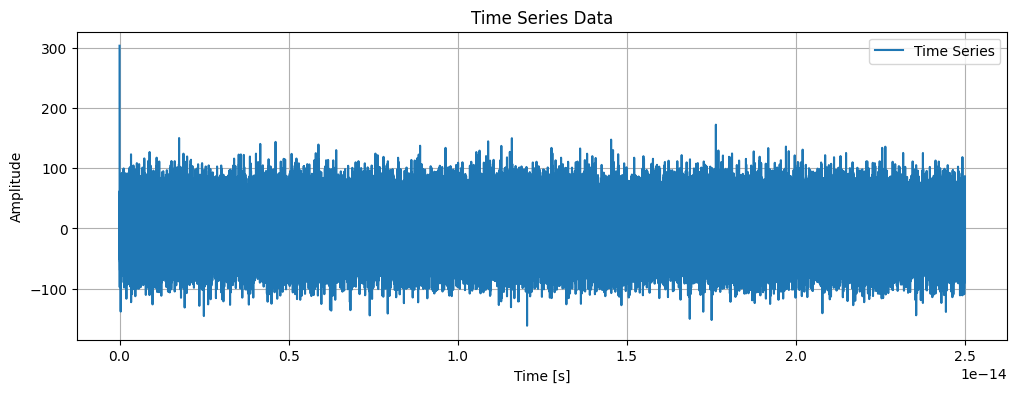

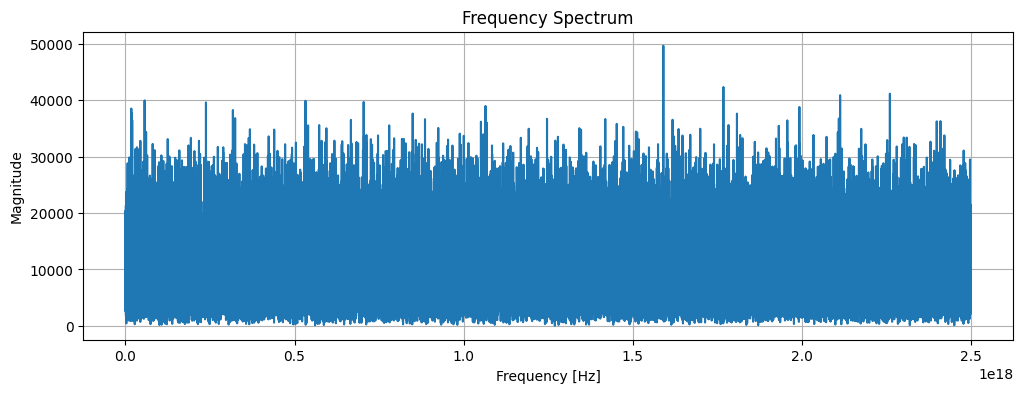

In [5]:
# Load data
data = pd.read_hdf("wille_simulated_data.h5")

# Check the structure
print("Data shape:", data.shape)
print("Columns:", data.columns.tolist())

# Extract time series data
time_series = data["time series"].values
time = data["time (ns)"].values / 1e9  # convert to seconds

# Plot the time series
plt.figure(figsize=(12, 4))
plt.plot(time, time_series, label="Time Series")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.title("Time Series Data")
plt.show()

# Plot FFT of the time series
freq = np.fft.fftfreq(len(time_series), time[1] - time[0])
X = np.fft.fft(time_series)

plt.figure(figsize=(12, 4))
plt.plot(freq[:len(freq)//2], np.abs(X[:len(X)//2]))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum")
plt.grid(True)
plt.show()

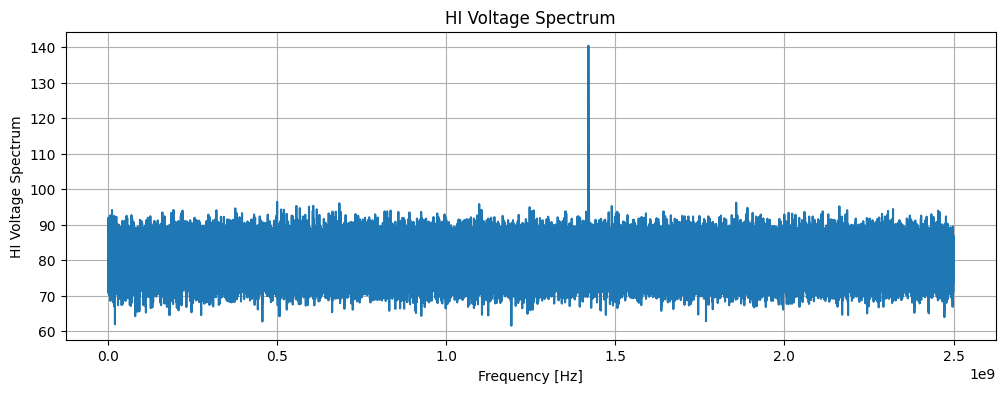

In [6]:
# Plot HI voltage spectrum
hi_voltage_spectrum = data["HI voltage spectrum"].values
frequencies = data["frequencies"].values

plt.figure(figsize=(12, 4))
plt.plot(frequencies, hi_voltage_spectrum)
plt.xlabel("Frequency [Hz]")
plt.ylabel("HI Voltage Spectrum")
plt.title("HI Voltage Spectrum")
plt.grid(True)
plt.show()

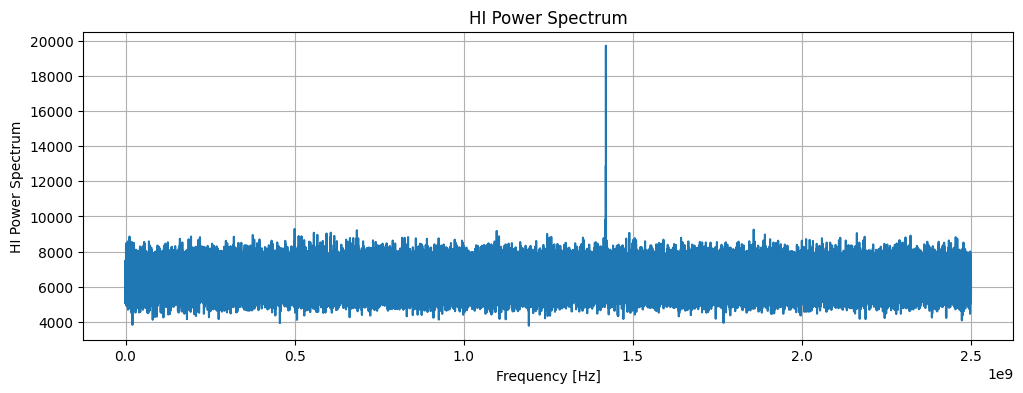

In [15]:
# Plot HI voltage spectrum
hi_voltage_spectrum = data["HI voltage spectrum"].values
frequencies = data["frequencies"].values

hi_power_spectrum = np.abs(hi_voltage_spectrum)**2

plt.figure(figsize=(12, 4))
plt.plot(frequencies, hi_power_spectrum)
plt.xlabel("Frequency [Hz]")
plt.ylabel("HI Power Spectrum")
plt.title("HI Power Spectrum")
plt.grid(True)
plt.show()

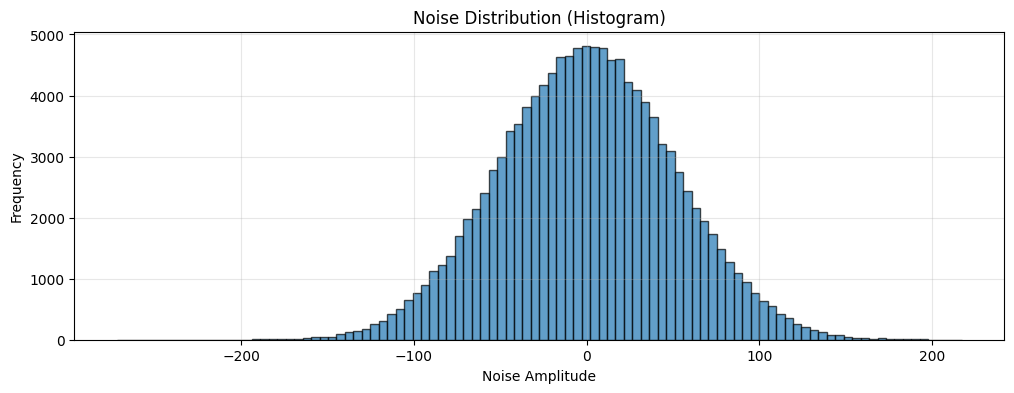

Noise Mean: -0.002697
Noise Std Dev: 50.663137
Noise Min: -272.038425
Noise Max: 217.424170


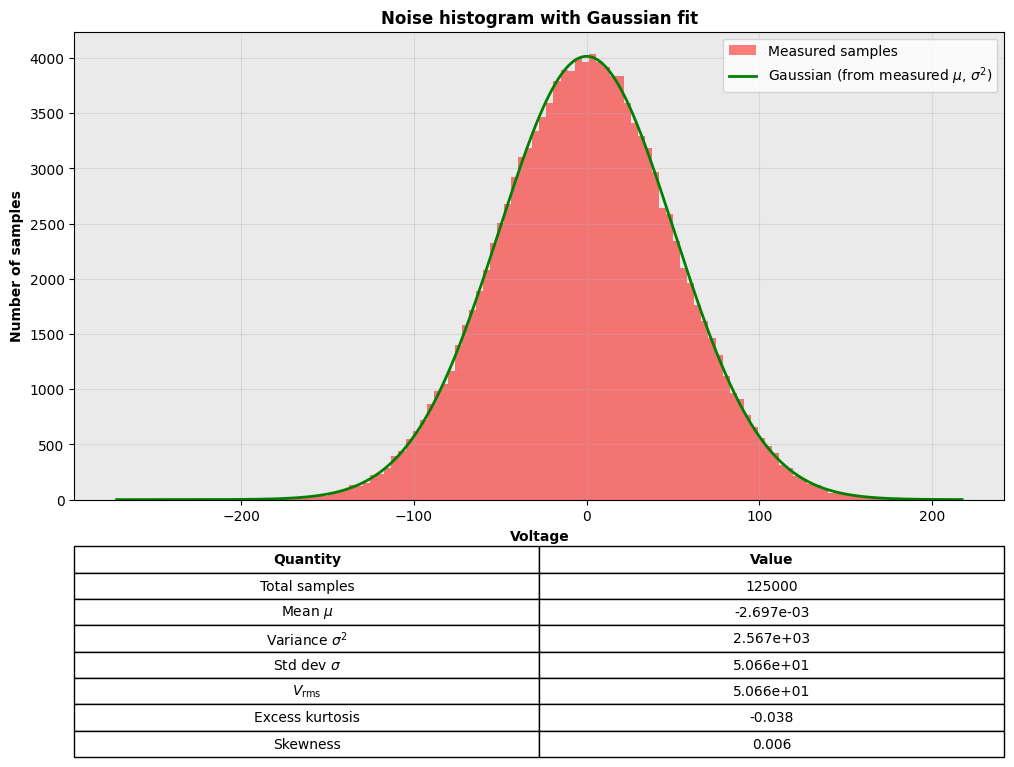

In [13]:
# Calculate and plot noise histogram
# Compute noise as the difference between consecutive samples (high-frequency variations)
noise = np.diff(time_series)

plt.figure(figsize=(12, 4))
plt.hist(noise, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel("Noise Amplitude")
plt.ylabel("Frequency")
plt.title("Noise Distribution (Histogram)")
plt.grid(True, alpha=0.3)
plt.show()

# Print noise statistics
print(f"Noise Mean: {np.mean(noise):.6f}")
print(f"Noise Std Dev: {np.std(noise):.6f}")
print(f"Noise Min: {np.min(noise):.6f}")
print(f"Noise Max: {np.max(noise):.6f}")

# Detailed noise analysis with Gaussian fit

fs = 5e6

# Use the noise we already computed (differences between consecutive samples)
x_all = noise  # noise array from previous cell

# 1) Mean + variance
mu = np.mean(x_all)
var = np.var(x_all, ddof=1)
sigma = np.sqrt(var)
vrms = np.sqrt(np.mean(x_all**2))

# 2) Histogram (counts) + scaled Gaussian
bins = 120

counts, edges = np.histogram(x_all, bins=bins, density=False)
bin_width = edges[1] - edges[0]

# Voltage axis for smooth Gaussian
x_gauss = np.linspace(edges[0], edges[-1], 1000)

# Gaussian PDF using measured mean and variance
gauss_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_gauss - mu) / sigma) ** 2
)

# Scale PDF → expected counts per bin
gauss_counts = gauss_pdf * len(x_all) * bin_width

# Gaussianity metrics
kurtosis_val = kurtosis(x_all, fisher=True, bias=False)
skewness_val = skew(x_all, bias=False)

# Build table
table_rows = [
    ["Total samples", f"{len(x_all):d}"],
    [r"Mean $\mu$", f"{mu:.3e}"],
    [r"Variance $\sigma^2$", f"{var:.3e}"],
    [r"Std dev $\sigma$", f"{sigma:.3e}"],
    [r"$V_{\mathrm{rms}}$", f"{vrms:.3e}"],
    ["Excess kurtosis", f"{kurtosis_val:.3f}"],
    ["Skewness", f"{skewness_val:.3f}"],
]

# Plot + table at bottom
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(x_all, bins=bins, alpha=0.5, color="red", label="Measured samples")
ax.plot(x_gauss, gauss_counts, linewidth=2, color="green",
        label=r"Gaussian (from measured $\mu$, $\sigma^2$)")

ax.set_xlabel("Voltage", weight="semibold")
ax.set_ylabel("Number of samples", weight="semibold")
ax.set_title("Noise histogram with Gaussian fit", weight="semibold")
ax.set_facecolor("#EAEAEA")
ax.grid(True, alpha=0.3)
ax.legend()

# Add table below plot
table = ax.table(
    cellText=table_rows,
    colLabels=["Quantity", "Value"],
    cellLoc="center",
    loc="bottom",
    bbox=[0.0, -0.55, 1.0, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(0.1, 0.1)

# Make room for table
plt.subplots_adjust(bottom=0.1)

# Make column headers bold
for (row, col), cell in table.get_celld().items():
    if row == 0:  # header row
        cell.set_text_props(weight="bold")

# Create figures directory if it doesn't exist
os.makedirs("figures", exist_ok=True)

plt.savefig("figures/noise_histogram_gaussian_fit.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
data_bighorn = np.load("bighorn_blackbody.npz")
samples = data_bighorn["samples"]
samples = samples[1:]

In [17]:
data_bighorn_zenith = np.load("bighorn_zenith.npz")
samples_zenith = data_bighorn_zenith["samples"]
samples_zenith = samples_zenith[1:]

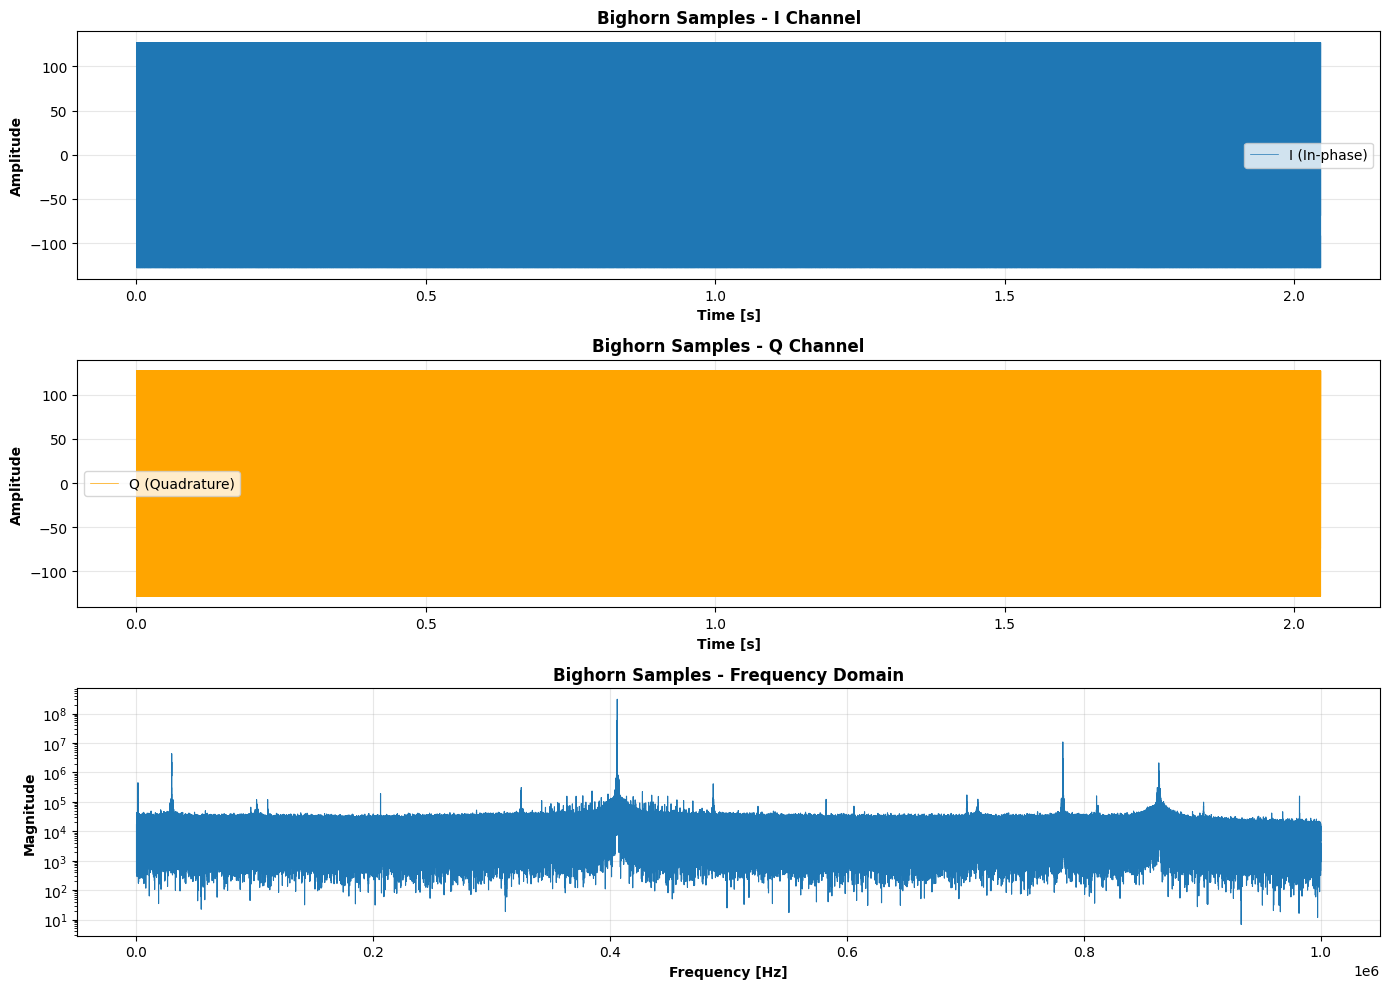

Total samples: 4091904
Duration: 2.045952e+00 seconds

I-channel stats:
  Mean: -5.843641e-01
  Std Dev: 9.988146e+01
  Min: -1.280000e+02
  Max: 1.270000e+02

Q-channel stats:
  Mean: -5.814960e-01
  Std Dev: 9.987945e+01
  Min: -1.280000e+02
  Max: 1.270000e+02


In [19]:
# Plot samples from bighorn data
# samples shape: (5, 2048, 2) - 5 blocks, 2048 samples each, 2 channels (I, Q)

fs = 2e6  # sampling frequency

# Flatten all blocks and extract I and Q channels
samples_flat = samples_zenith.reshape(-1, 2)  # reshape to (total_samples, 2)
I = samples_flat[:, 0]  # In-phase
Q = samples_flat[:, 1]  # Quadrature

# Generate time array
t = np.arange(len(I)) / fs

# Create complex signal
x = I + 1j * Q

# Plot time series
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Time domain - I channel
axes[0].plot(t, I, linewidth=0.5, label="I (In-phase)")
axes[0].set_xlabel("Time [s]", weight="semibold")
axes[0].set_ylabel("Amplitude", weight="semibold")
axes[0].set_title("Bighorn Samples - I Channel", weight="semibold")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Time domain - Q channel
axes[1].plot(t, Q, linewidth=0.5, label="Q (Quadrature)", color="orange")
axes[1].set_xlabel("Time [s]", weight="semibold")
axes[1].set_ylabel("Amplitude", weight="semibold")
axes[1].set_title("Bighorn Samples - Q Channel", weight="semibold")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# FFT plot
freq = np.fft.fftfreq(len(x), 1/fs)
X = np.fft.fft(x)
positive_freq_idx = freq > 0

axes[2].plot(freq[positive_freq_idx], np.abs(X[positive_freq_idx]), linewidth=0.8)
axes[2].set_xlabel("Frequency [Hz]", weight="semibold")
axes[2].set_ylabel("Magnitude", weight="semibold")
axes[2].set_title("Bighorn Samples - Frequency Domain", weight="semibold")
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

# Print statistics
print(f"Total samples: {len(I)}")
print(f"Duration: {t[-1]:.6e} seconds")
print(f"\nI-channel stats:")
print(f"  Mean: {np.mean(I):.6e}")
print(f"  Std Dev: {np.std(I):.6e}")
print(f"  Min: {np.min(I):.6e}")
print(f"  Max: {np.max(I):.6e}")
print(f"\nQ-channel stats:")
print(f"  Mean: {np.mean(Q):.6e}")
print(f"  Std Dev: {np.std(Q):.6e}")
print(f"  Min: {np.min(Q):.6e}")
print(f"  Max: {np.max(Q):.6e}")

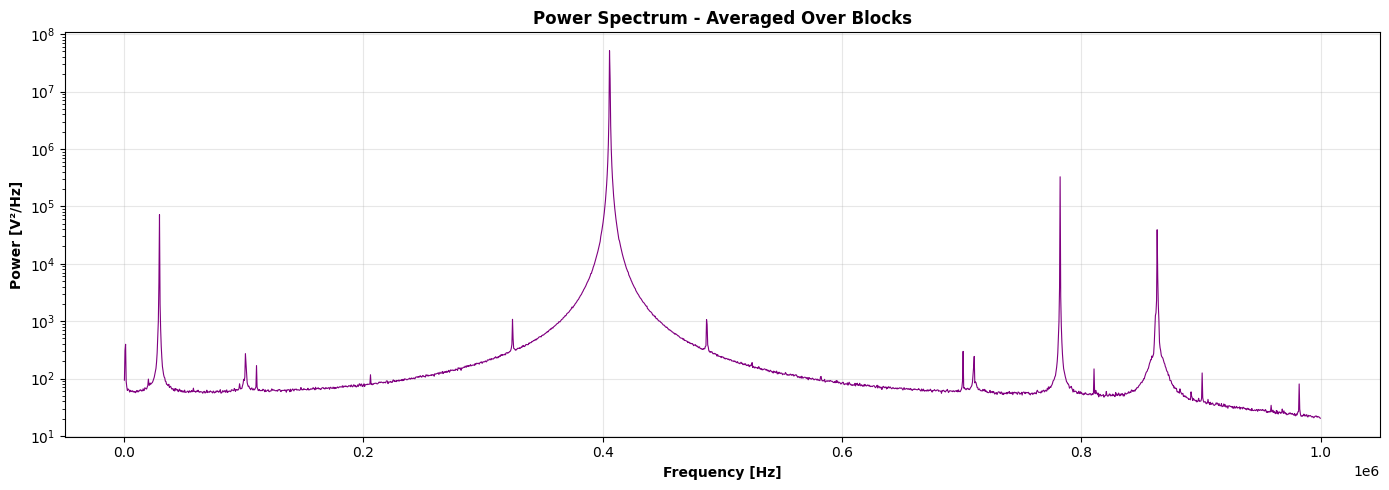

Number of blocks: 999
Total power (averaged): 8.158519e+07 V²
Max power: 5.155442e+07 V²
Max power frequency: 4.057617e+05 Hz


In [24]:
# Power spectrum - averaged over blocks
# Compute power spectrum for each block, then average

# Reshape to separate blocks
# samples shape after removal: (4, 2048, 2)
num_blocks = samples_zenith.shape[0]
num_samples_per_block = samples_zenith.shape[1]

# List to store power spectra
power_spectra = []

# Compute power spectrum for each block
for i in range(num_blocks):
    block_data = samples_zenith[i]  # shape (2048, 2)
    I_block = block_data[:, 0]
    Q_block = block_data[:, 1]
    x_block = I_block + 1j * Q_block
    
    # FFT
    X_block = np.fft.fft(x_block)
    freq_block = np.fft.fftfreq(len(x_block), 1/fs)
    
    # Power spectrum
    N = len(x_block)
    power_block = np.abs(X_block)**2 / N
    
    power_spectra.append(power_block)

# Average power spectra
power_avg = np.mean(power_spectra, axis=0)

# Single-sided spectrum
positive_freq_idx = freq_block > 0
power_avg_single_sided = power_avg[positive_freq_idx]
freq_single_sided = freq_block[positive_freq_idx]

# Plot averaged power spectrum
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(freq_single_sided, power_avg_single_sided, linewidth=0.8, color="purple")
ax.set_xlabel("Frequency [Hz]", weight="semibold")
ax.set_ylabel("Power [V²/Hz]", weight="semibold")
ax.set_title("Power Spectrum - Averaged Over Blocks", weight="semibold")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("Lab 2/figures/bighorn_power_spectrum_averaged.png", dpi=300, bbox_inches="tight")
plt.show()

# Print power spectrum stats
print(f"Number of blocks: {num_blocks}")
print(f"Total power (averaged): {np.sum(power_avg_single_sided):.6e} V²")
print(f"Max power: {np.max(power_avg_single_sided):.6e} V²")
print(f"Max power frequency: {freq_single_sided[np.argmax(power_avg_single_sided)]:.6e} Hz")

In [ ]:
# Power spectrum - averaged over blocks
# Compute power spectrum for each block, then average

# Reshape to separate blocks
# samples shape after removal: (4, 2048, 2)
num_blocks = samples.shape[0]
num_samples_per_block = samples.shape[1]

# List to store power spectra
power_spectra = []

# Compute power spectrum for each block
for i in range(num_blocks):
    block_data = samples[i]  # shape (2048, 2)
    I_block = block_data[:, 0]
    Q_block = block_data[:, 1]
    x_block = I_block + 1j * Q_block
    
    # FFT
    X_block = np.fft.fft(x_block)
    freq_block = np.fft.fftfreq(len(x_block), 1/fs)
    
    # Power spectrum
    N = len(x_block)
    power_block = np.abs(X_block)**2 / N
    
    power_spectra.append(power_block)

# Average power spectra
power_avg = np.mean(power_spectra, axis=0)

# Single-sided spectrum
positive_freq_idx = freq_block > 0
power_avg_single_sided = power_avg[positive_freq_idx]
freq_single_sided = freq_block[positive_freq_idx]

# Plot averaged power spectrum
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(freq_single_sided, power_avg_single_sided, linewidth=0.8, color="purple")
ax.set_xlabel("Frequency [Hz]", weight="semibold")
ax.set_ylabel("Power [V²/Hz]", weight="semibold")
ax.set_title("Power Spectrum - Averaged Over Blocks", weight="semibold")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("Lab 2/figures/bighorn_power_spectrum_averaged.png", dpi=300, bbox_inches="tight")
plt.show()

# Print power spectrum stats
print(f"Number of blocks: {num_blocks}")
print(f"Total power (averaged): {np.sum(power_avg_single_sided):.6e} V²")
print(f"Max power: {np.max(power_avg_single_sided):.6e} V²")
print(f"Max power frequency: {freq_single_sided[np.argmax(power_avg_single_sided)]:.6e} Hz")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:857: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7096: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


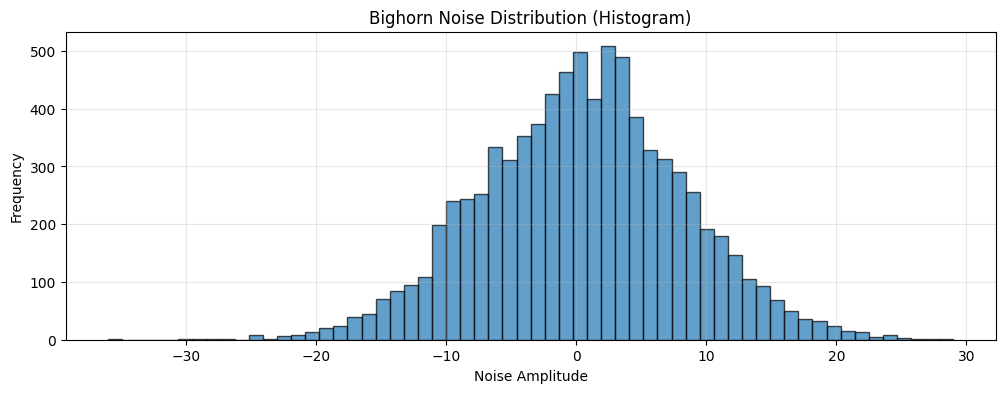

Noise Mean: -3.662556e-04+9.766817e-04j
Noise Std Dev: 1.104674e+01
Noise Min: -3.600000e+01-1.200000e+01j
Noise Max: 2.900000e+01+0.000000e+00j


In [25]:
# Noise distribution analysis for bighorn data
# Compute noise as the difference between consecutive samples

# Use the complex signal we already created
noise_bighorn = np.diff(x)

plt.figure(figsize=(12, 4))
plt.hist(noise_bighorn, bins=60, edgecolor='black', alpha=0.7)
plt.xlabel("Noise Amplitude")
plt.ylabel("Frequency")
plt.title("Bighorn Noise Distribution (Histogram)")
plt.grid(True, alpha=0.3)
plt.savefig("Lab 2/figures/bighorn_noise_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# Print noise statistics
print(f"Noise Mean: {np.mean(noise_bighorn):.6e}")
print(f"Noise Std Dev: {np.std(noise_bighorn):.6e}")
print(f"Noise Min: {np.min(noise_bighorn):.6e}")
print(f"Noise Max: {np.max(noise_bighorn):.6e}")

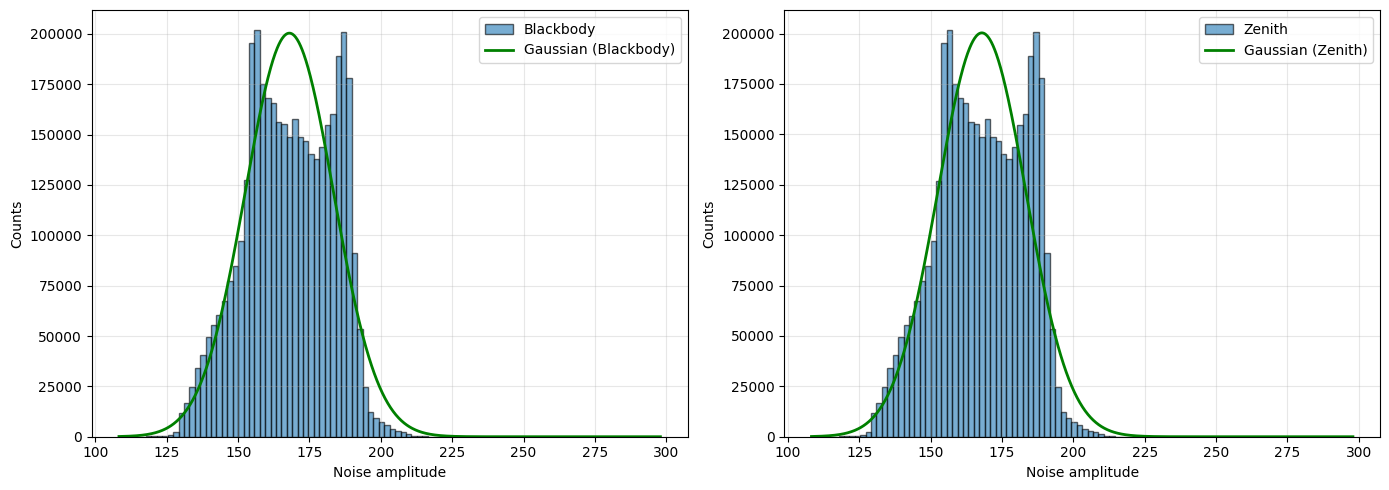

Blackbody noise stats: {'n_samples': 4091903, 'mean': np.float64(167.94739008572776), 'std': np.float64(15.458803740236355), 'min': np.float64(108.2450922675019), 'max': np.float64(297.9681191000138)}
Zenith noise stats: {'n_samples': 4087807, 'mean': np.float64(167.9412172369601), 'std': np.float64(15.444250168841515), 'min': np.float64(108.2450922675019), 'max': np.float64(297.9681191000138)}


In [43]:
# Noise histograms for each dataset (blackbody and zenith)

def plot_noise_hist_for(samples_arr, fs, label, ax):
    # concatenate blocks and form complex signal
    flat = samples_arr.reshape(-1, 2)
    x = flat[:,0] + 1j*flat[:,1]
    noise = np.diff(x)
    noise_abs = np.abs(noise)

    bins = 100
    counts, edges, _ = ax.hist(noise_abs, bins=bins, edgecolor='black', alpha=0.6, label=f"{label}")
    bin_width = edges[1] - edges[0]

    mu = np.mean(noise_abs)
    sigma = np.std(noise_abs, ddof=1)
    x_gauss = np.linspace(edges[0], edges[-1], 1000)
    gauss_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_gauss - mu)/sigma)**2)
    gauss_counts = gauss_pdf * len(noise_abs) * bin_width
    ax.plot(x_gauss, gauss_counts, color='green', linewidth=2, label=f"Gaussian ({label})")
    ax.set_xlabel('Noise amplitude')
    ax.set_ylabel('Counts')
    ax.grid(True, alpha=0.3)
    ax.legend()

    stats = {
        'n_samples': len(noise_abs),
        'mean': mu,
        'std': sigma,
        'min': np.min(noise_abs),
        'max': np.max(noise_abs)
    }
    return stats

fig, axs = plt.subplots(1, 2, figsize=(14,5))

stats_bb = plot_noise_hist_for(samples_blackbody, fs, 'Blackbody', axs[0])
stats_zn = plot_noise_hist_for(samples_zenith, fs, 'Zenith', axs[1])

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/noise_histograms_blackbody_zenith.png', dpi=300, bbox_inches='tight')
plt.show()

print('Blackbody noise stats:', stats_bb)
print('Zenith noise stats:', stats_zn)

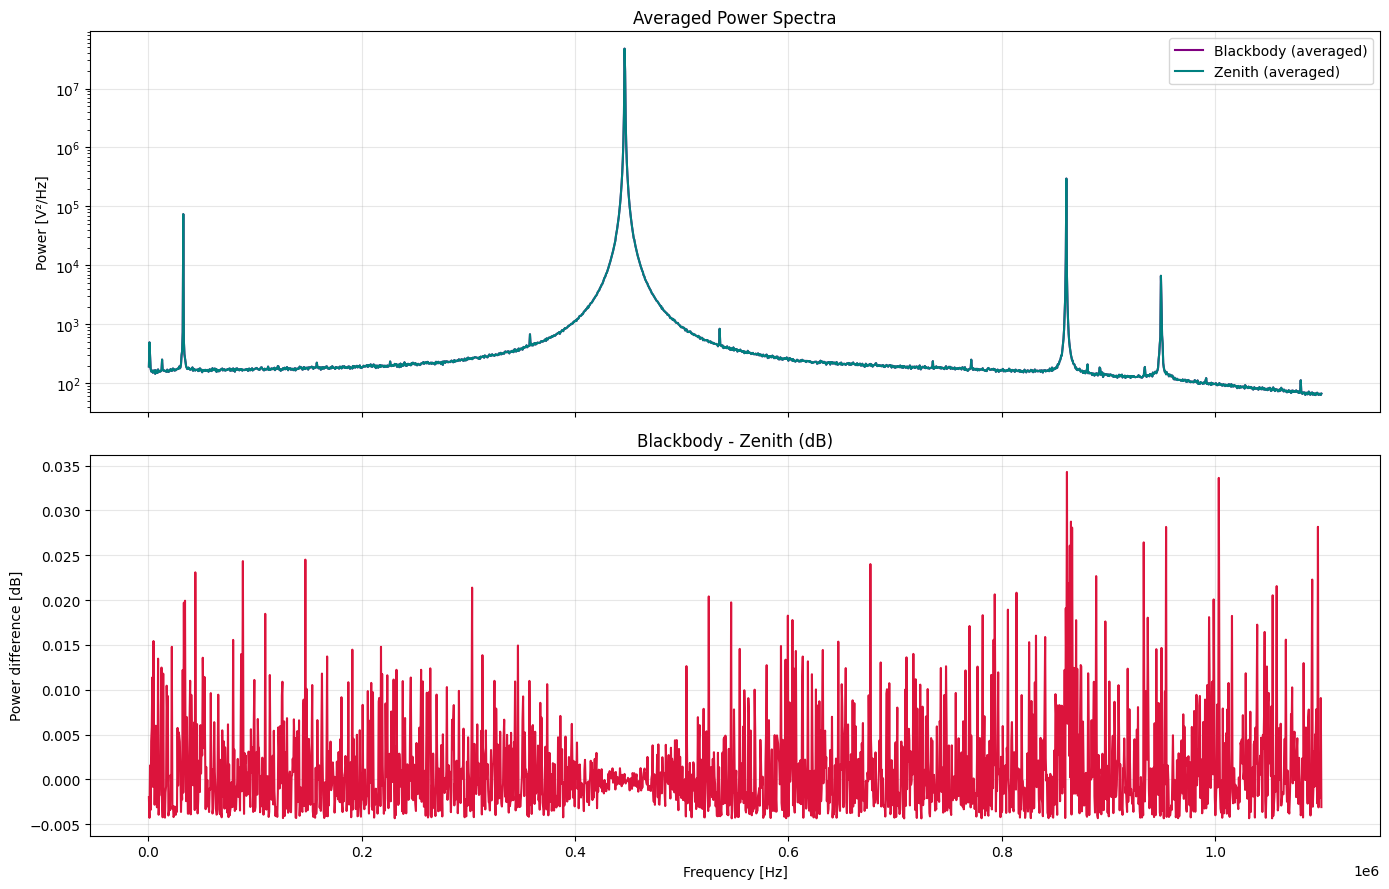

Frequency range: 5.371e+02 - 1.099e+06 Hz
Max dB difference: 0.034 dB at 8.610e+05 Hz
Min dB difference: -0.004 dB at 7.246e+05 Hz


In [41]:
# Compare averaged power spectra: blackbody minus zenith
# Computes averaged power spectrum per block for each dataset, then plots their difference

data_bighorn_zenith = np.load("bighorn_zenith.npz")
samples_zenith = data_bighorn_zenith["samples"]
samples_zenith = samples[1:]

data_bighorn = np.load("bighorn_blackbody.npz")
samples = data_bighorn["samples"]
samples = samples[1:]

# Ensure samples and samples_zenith are available
samples_blackbody = samples  # from bighorn_blackbody.npz
samples_zenith = samples_zenith  # from bighorn_zenith.npz

def averaged_power_spectrum(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    power_list = []
    for i in range(num_blocks):
        block = samples_arr[i]
        I_blk = block[:, 0]
        Q_blk = block[:, 1]
        x_blk = I_blk + 1j * Q_blk
        X_blk = np.fft.fft(x_blk)
        P_blk = np.abs(X_blk) ** 2 / N
        power_list.append(P_blk)
    power_avg = np.mean(power_list, axis=0)
    freqs = np.fft.fftfreq(N, 1 / fs)
    return freqs, power_avg

# Compute averaged spectra
freq_bb, power_bb = averaged_power_spectrum(samples_blackbody, fs)
freq_zn, power_zn = averaged_power_spectrum(samples_zenith, fs)

# Use positive frequencies (single-sided)
pos_idx = freq_bb > 0
fpos = freq_bb[pos_idx]
Pbb_pos = power_bb[pos_idx]
Pzn_pos = power_zn[pos_idx]

# Difference (linear) and in dB
eps = 1e-20
Pdiff = Pbb_pos - Pzn_pos
Pdiff_db = 10 * np.log10(Pbb_pos + eps) - 10 * np.log10(Pzn_pos + eps)

# Plot averaged spectra and their difference
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.plot(fpos, Pbb_pos, label="Blackbody (averaged)", color="purple")
ax1.plot(fpos, Pzn_pos, label="Zenith (averaged)", color="teal")
ax1.set_ylabel("Power [V²/Hz]")
ax1.set_title("Averaged Power Spectra")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(fpos, Pdiff_db, color="crimson")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Power difference [dB]")
ax2.set_title("Blackbody - Zenith (dB)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
os.makedirs("Lab 2/figures", exist_ok=True)
plt.savefig("Lab 2/figures/power_spectrum_difference_blackbody_minus_zenith.png", dpi=300, bbox_inches="tight")
plt.show()

# Print basic summary
print(f"Frequency range: {fpos[0]:.3e} - {fpos[-1]:.3e} Hz")
print(f"Max dB difference: {np.max(Pdiff_db):.3f} dB at {fpos[np.argmax(Pdiff_db)]:.3e} Hz")
print(f"Min dB difference: {np.min(Pdiff_db):.3f} dB at {fpos[np.argmin(Pdiff_db)]:.3e} Hz")

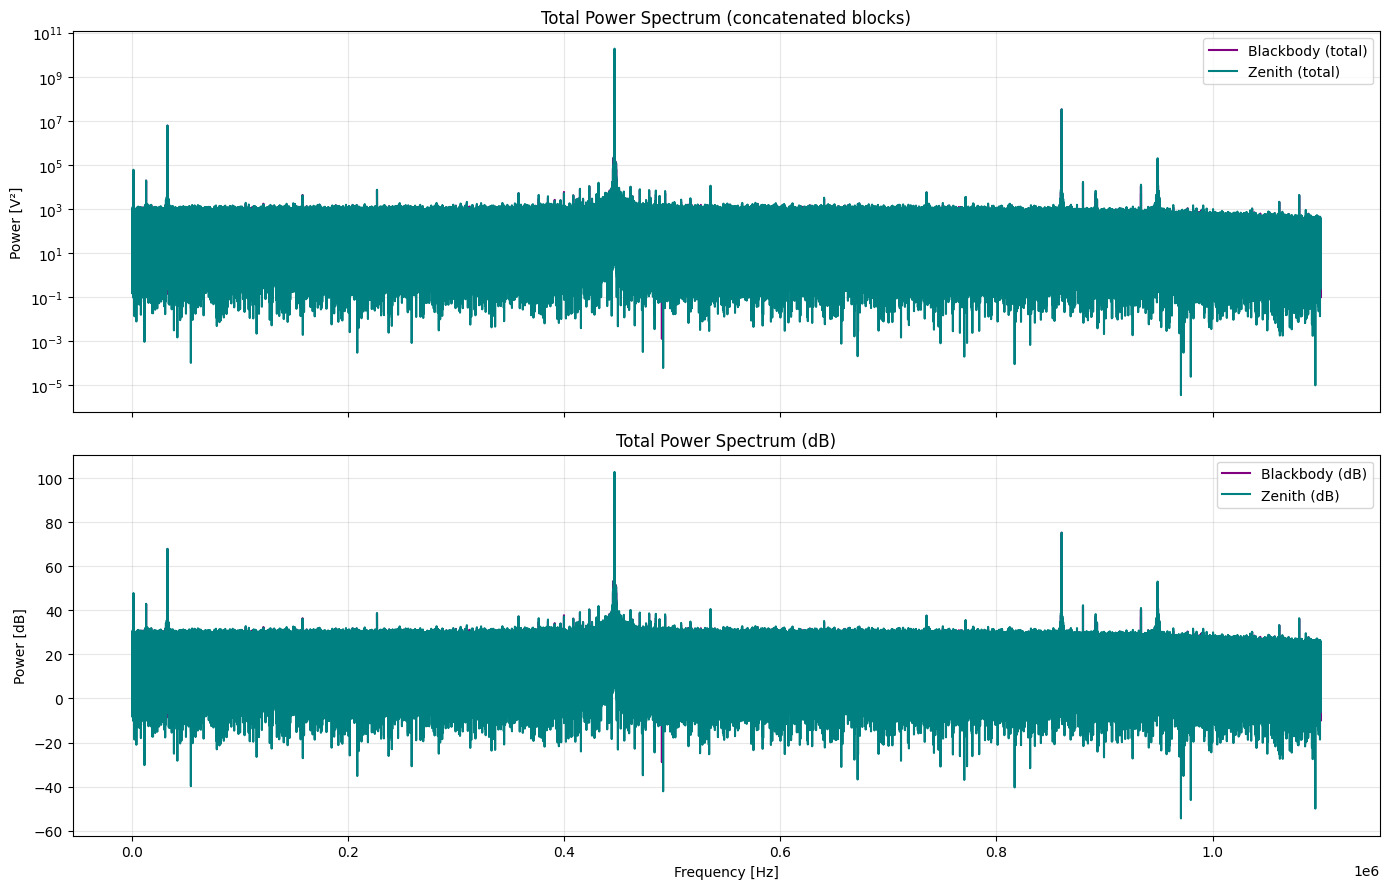

Blackbody total samples: 4091904
Zenith total samples: 4087808
Max power (blackbody): 1.539e+10 at 4.466e+05 Hz
Max power (zenith): 1.883e+10 at 4.466e+05 Hz


In [42]:
# Total power spectrum for all blocks (concatenate blocks)
# Concatenate all blocks for each dataset and compute power spectrum

def total_power_spectrum(samples_arr, fs):
    samples_flat = samples_arr.reshape(-1, 2)
    I_all = samples_flat[:, 0]
    Q_all = samples_flat[:, 1]
    x_all = I_all + 1j * Q_all
    N_all = len(x_all)
    X_all = np.fft.fft(x_all)
    freqs_all = np.fft.fftfreq(N_all, 1 / fs)
    power_all = np.abs(X_all) ** 2 / N_all
    return freqs_all, power_all

# Compute for blackbody and zenith
freq_bb_all, power_bb_all = total_power_spectrum(samples_blackbody, fs)
freq_zn_all, power_zn_all = total_power_spectrum(samples_zenith, fs)

# Single-sided (positive) components
pos_bb = freq_bb_all > 0
pos_zn = freq_zn_all > 0

f_bb_pos = freq_bb_all[pos_bb]
Pbb_pos = power_bb_all[pos_bb]

f_zn_pos = freq_zn_all[pos_zn]
Pzn_pos = power_zn_all[pos_zn]

# Ensure frequency axes match (they should, since N may be same)
# If lengths differ, interpolate to common freq grid
if len(f_bb_pos) != len(f_zn_pos) or not np.allclose(f_bb_pos, f_zn_pos):
    f_common = np.linspace(max(f_bb_pos[0], f_zn_pos[0]), min(f_bb_pos[-1], f_zn_pos[-1]), min(len(f_bb_pos), len(f_zn_pos)))
    Pbb_interp = np.interp(f_common, f_bb_pos, Pbb_pos)
    Pzn_interp = np.interp(f_common, f_zn_pos, Pzn_pos)
    f_plot = f_common
    Pbb_plot = Pbb_interp
    Pzn_plot = Pzn_interp
else:
    f_plot = f_bb_pos
    Pbb_plot = Pbb_pos
    Pzn_plot = Pzn_pos

# Plot total spectra (linear and dB)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.plot(f_plot, Pbb_plot, label='Blackbody (total)', color='purple')
ax1.plot(f_plot, Pzn_plot, label='Zenith (total)', color='teal')
ax1.set_ylabel('Power [V²]')
ax1.set_yscale('log')
ax1.set_title('Total Power Spectrum (concatenated blocks)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# dB plot
eps = 1e-20
ax2.plot(f_plot, 10 * np.log10(Pbb_plot + eps), label='Blackbody (dB)', color='purple')
ax2.plot(f_plot, 10 * np.log10(Pzn_plot + eps), label='Zenith (dB)', color='teal')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power [dB]')
ax2.set_title('Total Power Spectrum (dB)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/total_power_spectra_blackbody_vs_zenith.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print('Blackbody total samples:', samples_blackbody.reshape(-1,2).shape[0])
print('Zenith total samples:', samples_zenith.reshape(-1,2).shape[0])
print(f'Max power (blackbody): {np.max(Pbb_plot):.3e} at {f_plot[np.argmax(Pbb_plot)]:.3e} Hz')
print(f'Max power (zenith): {np.max(Pzn_plot):.3e} at {f_plot[np.argmax(Pzn_plot)]:.3e} Hz')

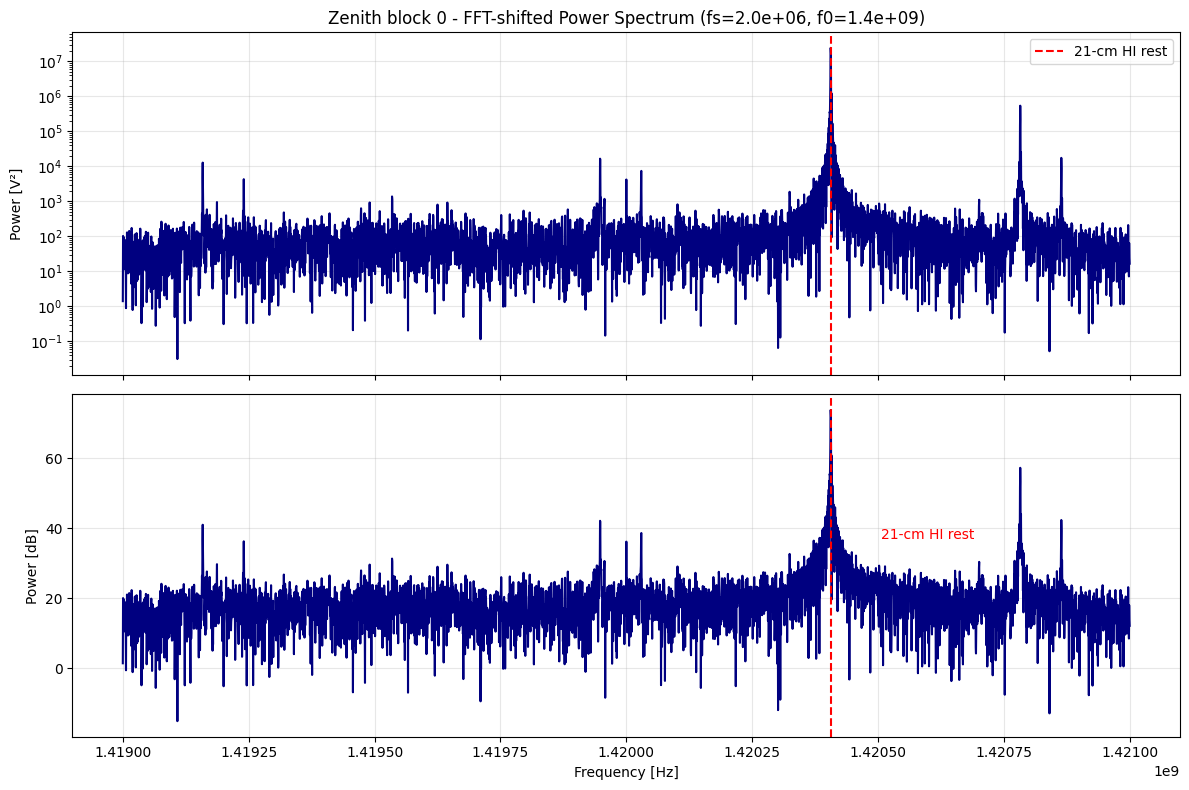

Peak power: 2.410e+07 V² at 1.420e+09 Hz (block 0)


In [ ]:
# Single-block power spectrum for zenith dataset (fftshifted, with center-frequency offset)
# Loads `bighorn_zenith.npz`, selects one block, computes and plots its fftshifted power spectrum

data_zen = np.load("bighorn_zenith.npz")
samples_zen = data_zen["samples"]

# choose block index (0-based). Change if you want a different block.
block_idx = 0
if block_idx >= samples_zen.shape[0]:
    raise IndexError(f"block_idx {block_idx} out of range (0..{samples_zen.shape[0]-1})")

block = samples_zen[block_idx]  # shape (nsamples, 2)
I_blk = block[:, 0]
Q_blk = block[:, 1]
x_blk = I_blk + 1j * Q_blk

# sampling frequency and center frequency (collection offset)
fs_local = 2e6  # sampling rate
f_offset = 1420e6  # center frequency offset

N = len(x_blk)
X_blk = np.fft.fft(x_blk)
# shift both FFT and frequency axis
X_shift = np.fft.fftshift(X_blk)
freqs = np.fft.fftfreq(N, 1 / fs_local)
freqs_shift = np.fft.fftshift(freqs) + f_offset

# Power (per-bin) normalized
power_shift = (np.abs(X_shift)**2) / N

# 21-cm hydrogen rest frequency with Doppler adjustment
f_HI_rest = 1420.40575177e6
c = 3e8  # Speed of light [m/s]
v_lsr = 0.0  # Line-of-sight velocity [km/s]. Positive = receding, Negative = approaching
f_HI = f_HI_rest * (1.0 - v_lsr * 1000 / c)  # Doppler formula

# Plot full fftshifted spectrum (linear and dB)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(freqs_shift, power_shift, color='navy')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title(f'Zenith block {block_idx} - FFT-shifted Power Spectrum (fs={fs_local:.1e}, f0={f_offset:.1e})')
ax1.grid(True, alpha=0.3)

# mark the 21-cm HI line (Doppler shifted)
ax1.axvline(f_HI, color='red', linestyle='--', linewidth=1.5, label=f'21-cm HI (v_lsr = {v_lsr:.1f} km/s)')
ax1.legend()

ax2.plot(freqs_shift, 10 * np.log10(power_shift + 1e-20), color='navy')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power [dB]')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--', linewidth=1.5)
ax2.annotate('21-cm HI rest', xy=(f_HI, np.max(10 * np.log10(power_shift + 1e-20))/2), xytext=(f_HI + 1e5, np.max(10 * np.log10(power_shift + 1e-20))/2), color='red')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/zenith_block0_power_spectrum_shifted_with_HI.png', dpi=300, bbox_inches='tight')
plt.show()

# print peak (find max in dB)
peak_idx = np.argmax(power_shift)
print(f"Peak power: {power_shift[peak_idx]:.3e} V² at {freqs_shift[peak_idx]:.3e} Hz (block {block_idx})")

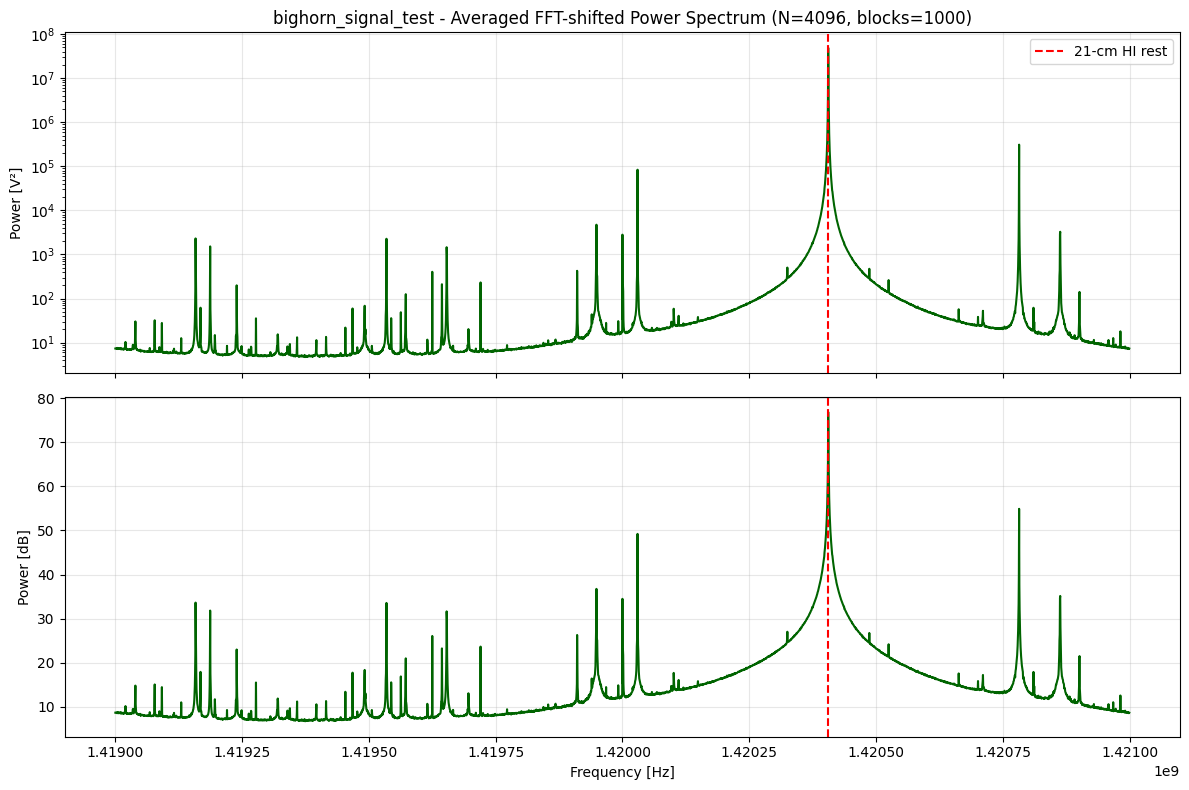

Peak averaged power (signal_test): 4.878e+07 V² at 1.420e+09 Hz


In [5]:
# Averaged fftshifted power spectrum for bighorn_signal_test.npz
# Load the new dataset, compute fftshifted power per block, average and plot

data_sig = np.load("bighorn_signal_test.npz")
samples_sig = data_sig["samples"]

# sampling frequency and center frequency (collection offset)
fs_local = 2e6
f_offset = 1420e6

num_blocks = samples_sig.shape[0]
N = samples_sig.shape[1]

power_acc = np.zeros(N, dtype=float)
for i in range(num_blocks):
    block = samples_sig[i]
    I_blk = block[:, 0]
    Q_blk = block[:, 1]
    x_blk = I_blk + 1j * Q_blk
    X_blk = np.fft.fft(x_blk)
    X_shift = np.fft.fftshift(X_blk)
    power_shift = (np.abs(X_shift)**2) / N
    power_acc += power_shift

power_avg_sig = power_acc / num_blocks

# frequency axis (shifted) and apply center offset
freqs = np.fft.fftfreq(N, 1 / fs_local)
freqs_shift = np.fft.fftshift(freqs) + f_offset

# 21-cm hydrogen rest frequency
f_HI = 1420.40575177e6

# Plot averaged fftshifted spectrum for signal_test
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(freqs_shift, power_avg_sig, color='darkgreen')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title(f'bighorn_signal_test - Averaged FFT-shifted Power Spectrum (N={N}, blocks={num_blocks})')
ax1.grid(True, alpha=0.3)
ax1.axvline(f_HI, color='red', linestyle='--', linewidth=1.5, label='21-cm HI rest')
ax1.legend()

ax2.plot(freqs_shift, 10 * np.log10(power_avg_sig + 1e-20), color='darkgreen')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power [dB]')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/signal_test_avg_shifted_power_spectrum_with_HI.png', dpi=300, bbox_inches='tight')
plt.show()

# report peak
peak_idx = np.argmax(power_avg_sig)
print(f"Peak averaged power (signal_test): {power_avg_sig[peak_idx]:.3e} V² at {freqs_shift[peak_idx]:.3e} Hz")

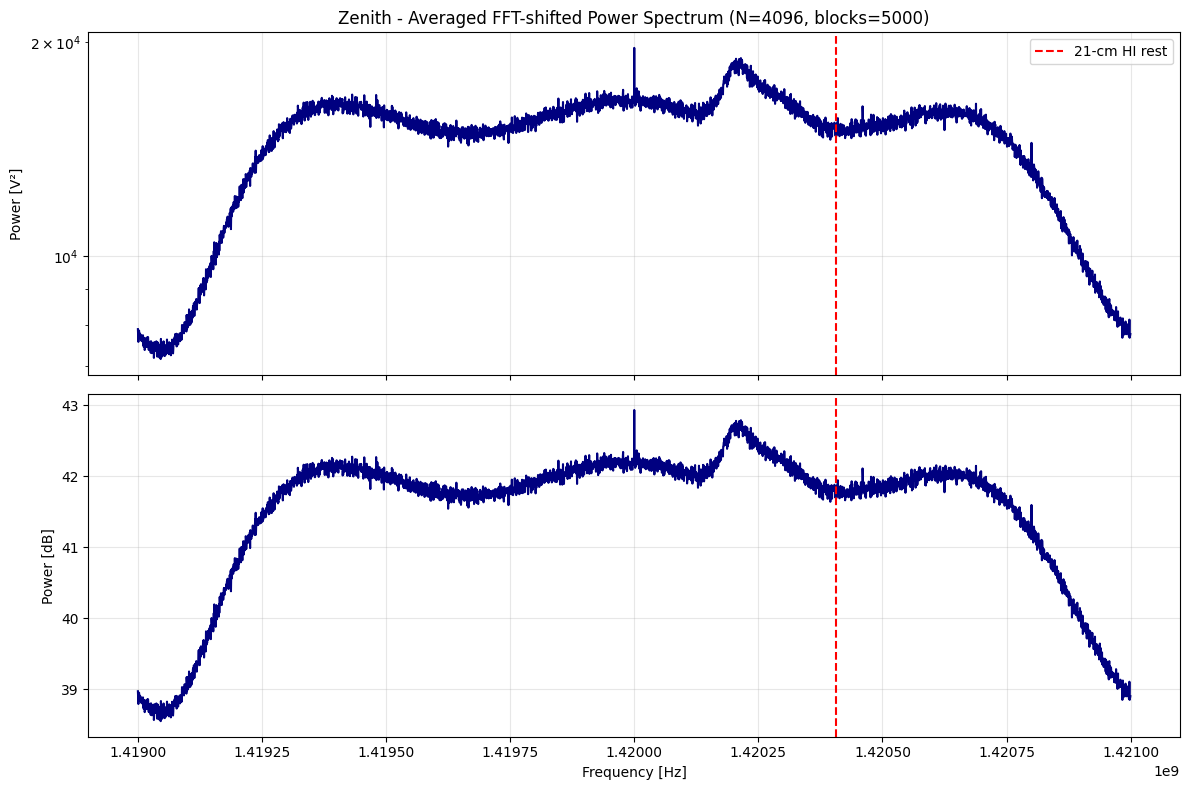

Peak averaged power: 1.965e+04 V² at 1.420e+09 Hz


In [2]:
# Averaged fftshifted power spectrum over all zenith blocks
# Loads `bighorn_zenith.npz`, computes fftshifted power per block, averages and plots

data_zen = np.load("bighorn_galactic_plane.npz")
samples_zen = data_zen["samples"]

# sampling frequency and center frequency (collection offset)
fs_local = 2e6
f_offset = 1420e6

num_blocks = samples_zen.shape[0]
N = samples_zen.shape[1]

# accumulate shifted power spectra
power_acc = np.zeros(N, dtype=float)
for i in range(num_blocks):
    block = samples_zen[i]
    I_blk = block[:, 0]
    Q_blk = block[:, 1]
    x_blk = I_blk + 1j * Q_blk
    X_blk = np.fft.fft(x_blk)
    X_shift = np.fft.fftshift(X_blk)
    power_shift = (np.abs(X_shift)**2) / N
    power_acc += power_shift

power_avg = power_acc / num_blocks

# frequency axis (shifted) and apply center offset
freqs = np.fft.fftfreq(N, 1 / fs_local)
freqs_shift = np.fft.fftshift(freqs) + f_offset

# 21-cm hydrogen rest frequency
f_HI = 1420.40575177e6

# Plot averaged fftshifted spectrum
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(freqs_shift, power_avg, color='navy')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title(f'Zenith - Averaged FFT-shifted Power Spectrum (N={N}, blocks={num_blocks})')
ax1.grid(True, alpha=0.3)
ax1.axvline(f_HI, color='red', linestyle='--', linewidth=1.5, label='21-cm HI rest')
ax1.legend()

ax2.plot(freqs_shift, 10 * np.log10(power_avg + 1e-20), color='navy')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power [dB]')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/zenith_avg_shifted_power_spectrum_with_HI.png', dpi=300, bbox_inches='tight')
plt.show()

# report peak
peak_idx = np.argmax(power_avg)
print(f"Peak averaged power: {power_avg[peak_idx]:.3e} V² at {freqs_shift[peak_idx]:.3e} Hz")

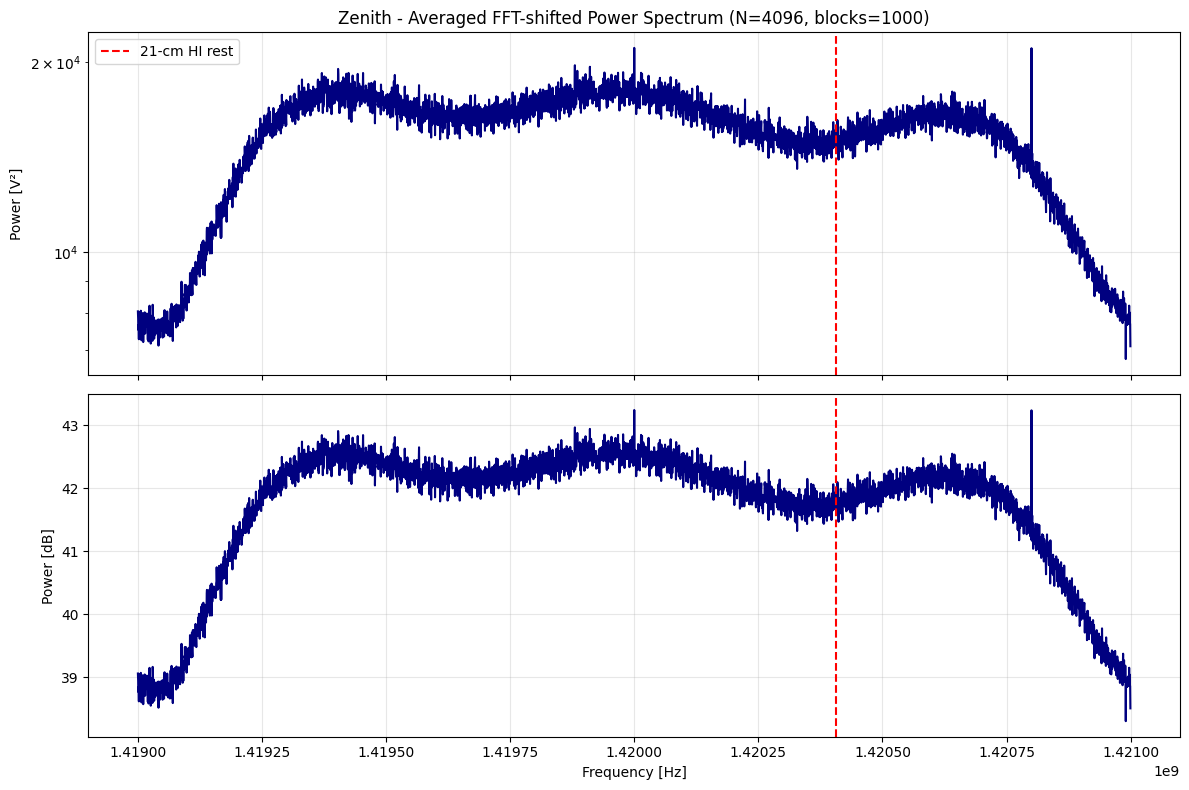

Peak averaged power: 2.109e+04 V² at 1.420e+09 Hz


In [8]:
# Averaged fftshifted power spectrum over all zenith blocks
# Loads `bighorn_zenith.npz`, computes fftshifted power per block, averages and plots

data_zen = np.load("bighorn_wall_blackbody.npz")
samples_zen = data_zen["samples"]

# sampling frequency and center frequency (collection offset)
fs_local = 2e6
f_offset = 1420e6

num_blocks = samples_zen.shape[0]
N = samples_zen.shape[1]

# accumulate shifted power spectra
power_acc = np.zeros(N, dtype=float)
for i in range(num_blocks):
    block = samples_zen[i]
    I_blk = block[:, 0]
    Q_blk = block[:, 1]
    x_blk = I_blk + 1j * Q_blk
    X_blk = np.fft.fft(x_blk)
    X_shift = np.fft.fftshift(X_blk)
    power_shift = (np.abs(X_shift)**2) / N
    power_acc += power_shift

power_avg = power_acc / num_blocks

# frequency axis (shifted) and apply center offset
freqs = np.fft.fftfreq(N, 1 / fs_local)
freqs_shift = np.fft.fftshift(freqs) + f_offset

# 21-cm hydrogen rest frequency
f_HI = 1420.40575177e6

# Plot averaged fftshifted spectrum
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(freqs_shift, power_avg, color='navy')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title(f'Zenith - Averaged FFT-shifted Power Spectrum (N={N}, blocks={num_blocks})')
ax1.grid(True, alpha=0.3)
ax1.axvline(f_HI, color='red', linestyle='--', linewidth=1.5, label='21-cm HI rest')
ax1.legend()

ax2.plot(freqs_shift, 10 * np.log10(power_avg + 1e-20), color='navy')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power [dB]')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/zenith_avg_shifted_power_spectrum_with_HI.png', dpi=300, bbox_inches='tight')
plt.show()

# report peak
peak_idx = np.argmax(power_avg)
print(f"Peak averaged power: {power_avg[peak_idx]:.3e} V² at {freqs_shift[peak_idx]:.3e} Hz")

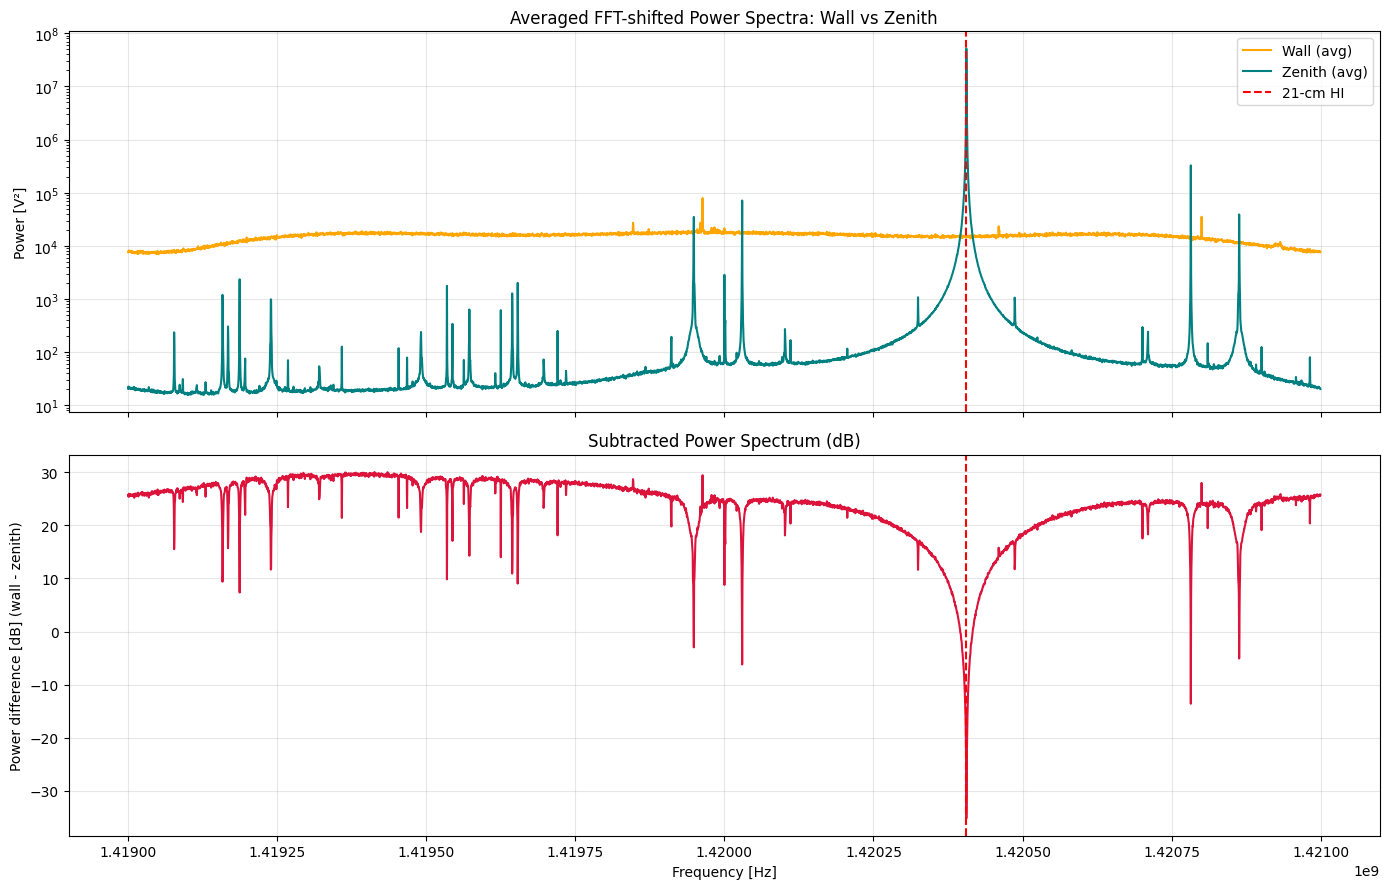

Max dB difference: 30.027 dB at 1.419e+09 Hz
Min dB difference: -35.180 dB at 1.420e+09 Hz
Saved figure: Lab 2/figures/wall_minus_zenith_difference.png


In [10]:
# Subtracted averaged fftshifted power spectrum: wall - zenith
# Loads `bighorn_wall.npz` and `bighorn_zenith.npz`, averages fftshifted power per block, subtracts and plots

fn_wall = "bighorn_wall.npz"
fn_zenith = "bighorn_zenith.npz"

data_wall = np.load(fn_wall)
data_zenith = np.load(fn_zenith)

samples_wall = data_wall["samples"]
samples_zenith = data_zenith["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) / N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_wall, Pwall = avg_shifted_power(samples_wall, fs_local)
freq_zenith, Pzenith = avg_shifted_power(samples_zenith, fs_local)

# align frequency axes if needed
if len(freq_wall) != len(freq_zenith) or not np.allclose(freq_wall, freq_zenith):
    fmin = max(freq_wall.min(), freq_zenith.min())
    fmax = min(freq_wall.max(), freq_zenith.max())
    npts = min(len(freq_wall), len(freq_zenith))
    f_common = np.linspace(fmin, fmax, npts)
    Pwall_i = np.interp(f_common, freq_wall, Pwall)
    Pzenith_i = np.interp(f_common, freq_zenith, Pzenith)
    f_plot = f_common
    Pwall_plot = Pwall_i
    Pzenith_plot = Pzenith_i
else:
    f_plot = freq_wall
    Pwall_plot = Pwall
    Pzenith_plot = Pzenith

# subtraction
Pdiff = Pwall_plot - Pzenith_plot
Pdiff_db = 10*np.log10(Pwall_plot + 1e-20) - 10*np.log10(Pzenith_plot + 1e-20)

# 21-cm line
f_HI = 1420.40575177e6

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(14,9), sharex=True)
ax1.plot(f_plot, Pwall_plot, label='Wall (avg)', color='orange')
ax1.plot(f_plot, Pzenith_plot, label='Zenith (avg)', color='teal')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra: Wall vs Zenith')
ax1.grid(True, alpha=0.3)
ax1.axvline(f_HI, color='red', linestyle='--', label='21-cm HI')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (wall - zenith)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
outfn = 'Lab 2/figures/wall_minus_zenith_difference.png'
plt.savefig(outfn, dpi=300, bbox_inches='tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"Saved figure: {outfn}")

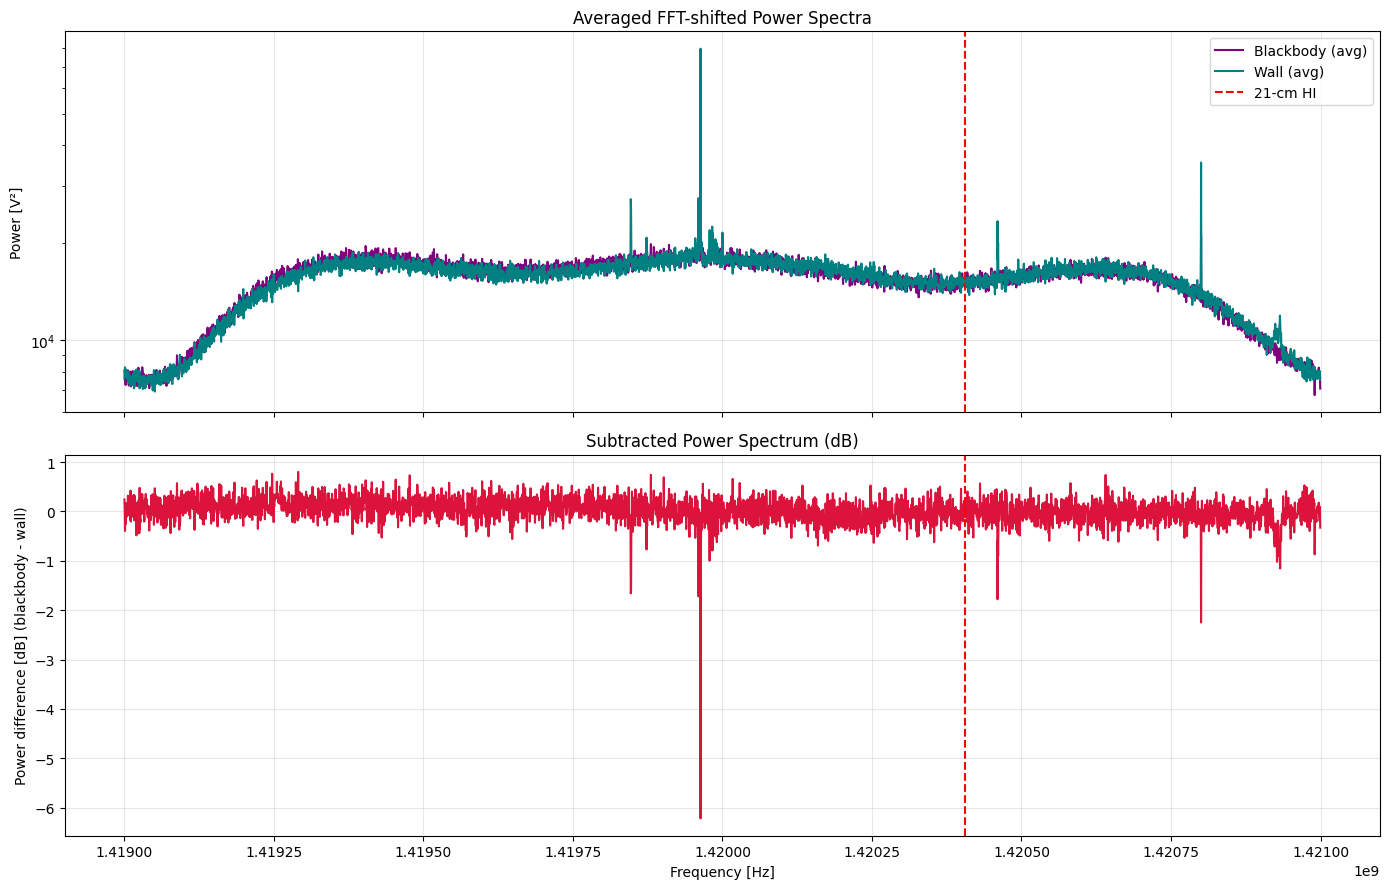

Max dB difference: 0.801 dB at 1.419e+09 Hz
Min dB difference: -6.220 dB at 1.420e+09 Hz
Saved figure: Lab 2/figures/wall_blackbody_minus_wall_difference.png


In [9]:
# Subtracted averaged fftshifted power spectrum: blackbody - wall
# Loads `bighorn_wall_blackbody.npz` and `bighorn_wall.npz`, averages fftshifted power per block, subtracts and plots

fn_bb = "bighorn_wall_blackbody.npz"
fn_wall = "bighorn_wall.npz"

data_bb = np.load(fn_bb)
data_wall = np.load(fn_wall)

samples_bb = data_bb["samples"]
samples_wall = data_wall["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) / N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_bb, Pbb = avg_shifted_power(samples_bb, fs_local)
freq_wall, Pwall = avg_shifted_power(samples_wall, fs_local)

# align frequency axes if needed
if len(freq_bb) != len(freq_wall) or not np.allclose(freq_bb, freq_wall):
    # interpolate to common grid (use intersection)
    fmin = max(freq_bb.min(), freq_wall.min())
    fmax = min(freq_bb.max(), freq_wall.max())
    npts = min(len(freq_bb), len(freq_wall))
    f_common = np.linspace(fmin, fmax, npts)
    Pbb_i = np.interp(f_common, freq_bb, Pbb)
    Pwall_i = np.interp(f_common, freq_wall, Pwall)
    f_plot = f_common
    Pbb_plot = Pbb_i
    Pwall_plot = Pwall_i
else:
    f_plot = freq_bb
    Pbb_plot = Pbb
    Pwall_plot = Pwall

# subtraction
Pdiff = Pbb_plot - Pwall_plot
Pdiff_db = 10*np.log10(Pbb_plot + 1e-20) - 10*np.log10(Pwall_plot + 1e-20)

# 21-cm line
f_HI = 1420.40575177e6

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(14,9), sharex=True)
ax1.plot(f_plot, Pbb_plot, label='Blackbody (avg)', color='purple')
ax1.plot(f_plot, Pwall_plot, label='Wall (avg)', color='teal')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra')
ax1.grid(True, alpha=0.3)
ax1.axvline(f_HI, color='red', linestyle='--', label='21-cm HI')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (blackbody - wall)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
outfn = 'Lab 2/figures/wall_blackbody_minus_wall_difference.png'
plt.savefig(outfn, dpi=300, bbox_inches='tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"Saved figure: {outfn}")

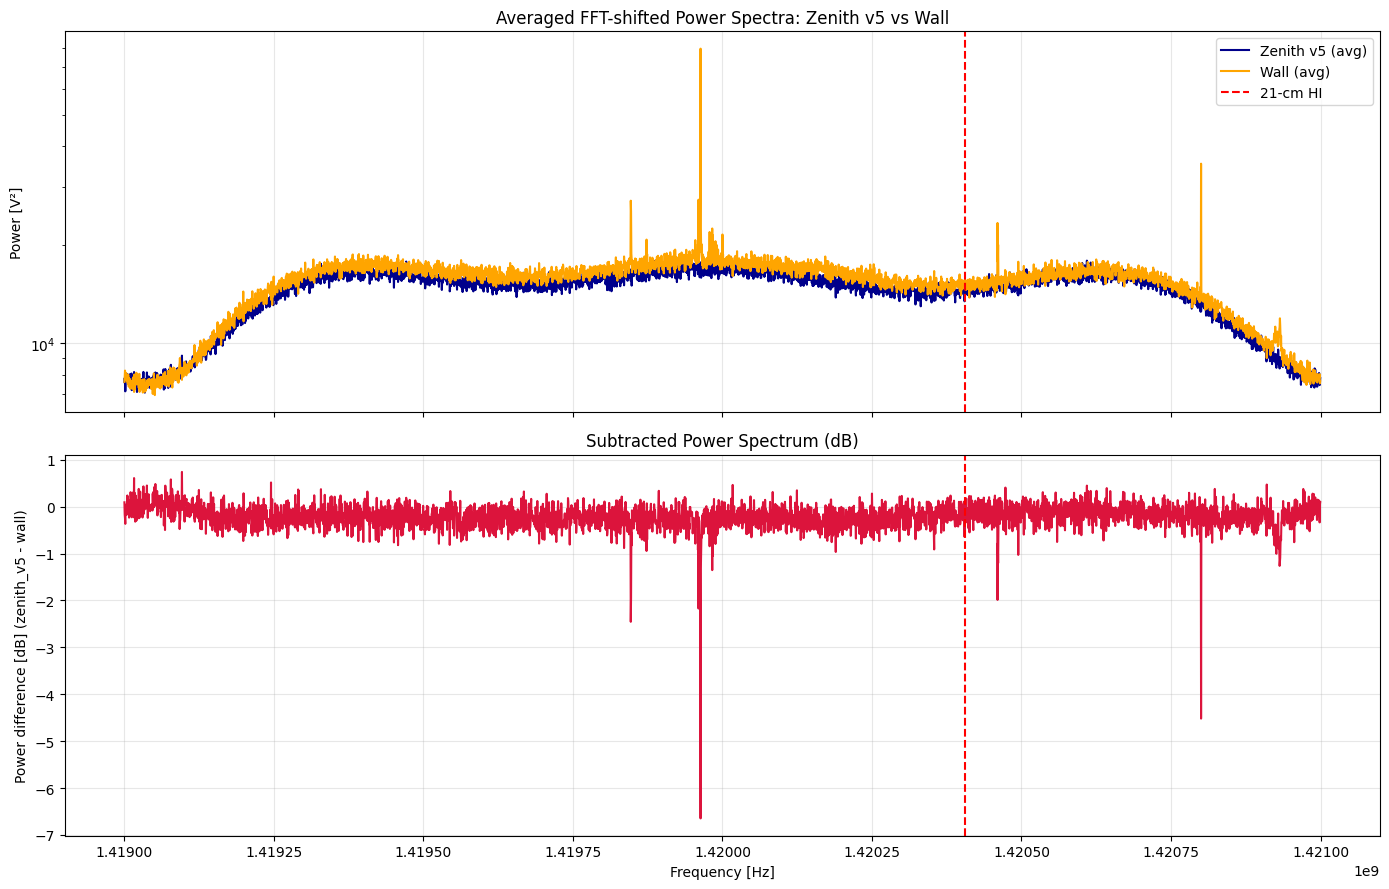

Max dB difference: 0.741 dB at 1.419e+09 Hz
Min dB difference: -6.647 dB at 1.420e+09 Hz
Saved figure: Lab 2/figures/zenith_v5_minus_wall_difference.png


In [ ]:
# Subtracted averaged fftshifted power spectrum: zenith_v5 - wall
# Loads `bighorn_zenith_v5.npz` and `bighorn_wall.npz`, averages fftshifted power per block, subtracts and plots

fn_zen_v5 = "bighorn_zenith_v5.npz"
fn_wall = "bighorn_wall.npz"

data_zen_v5 = np.load(fn_zen_v5)
data_wall = np.load(fn_wall)

samples_zen_v5 = data_zen_v5["samples"]
samples_wall = data_wall["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) / N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_zen_v5, Pzen_v5 = avg_shifted_power(samples_zen_v5, fs_local)
freq_wall, Pwall = avg_shifted_power(samples_wall, fs_local)

# align frequency axes if needed
if len(freq_zen_v5) != len(freq_wall) or not np.allclose(freq_zen_v5, freq_wall):
    fmin = max(freq_zen_v5.min(), freq_wall.min())
    fmax = min(freq_zen_v5.max(), freq_wall.max())
    npts = min(len(freq_zen_v5), len(freq_wall))
    f_common = np.linspace(fmin, fmax, npts)
    Pzen_v5_i = np.interp(f_common, freq_zen_v5, Pzen_v5)
    Pwall_i = np.interp(f_common, freq_wall, Pwall)
    f_plot = f_common
    Pzen_v5_plot = Pzen_v5_i
    Pwall_plot = Pwall_i
else:
    f_plot = freq_zen_v5
    Pzen_v5_plot = Pzen_v5
    Pwall_plot = Pwall

# subtraction
Pdiff = Pzen_v5_plot - Pwall_plot
Pdiff_db = 10*np.log10(Pzen_v5_plot + 1e-20) - 10*np.log10(Pwall_plot + 1e-20)

# 21-cm line with Doppler adjustment
f_HI_rest = 1420.40575177e6
c = 3e8  # Speed of light [m/s]
v_lsr = 0.0  # Line-of-sight velocity [km/s]. Positive = receding, Negative = approaching
f_HI = f_HI_rest * (1.0 - v_lsr * 1000 / c)  # Doppler formula

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(14,9), sharex=True)
ax1.plot(f_plot, Pzen_v5_plot, label='Zenith v5 (avg)', color='darkblue')
ax1.plot(f_plot, Pwall_plot, label='Wall (avg)', color='orange')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra: Zenith v5 vs Wall')
ax1.grid(True, alpha=0.3)
ax1.axvline(f_HI, color='red', linestyle='--', label=f'21-cm HI (v_lsr = {v_lsr:.1f} km/s)')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (zenith_v5 - wall)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
outfn = 'Lab 2/figures/zenith_v5_minus_wall_difference.png'
plt.savefig(outfn, dpi=300, bbox_inches='tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"Saved figure: {outfn}")

In [ ]:
# Noise histograms for each dataset (blackbody and zenith)

def plot_noise_hist_for(samples_arr, fs, label, ax):
    # concatenate blocks and form complex signal
    flat = samples_arr.reshape(-1, 2)
    x = flat[:,0] + 1j*flat[:,1]
    noise = np.diff(x)
    noise_abs = np.abs(noise)

    bins = 100
    counts, edges, _ = ax.hist(noise_abs, bins=bins, edgecolor='black', alpha=0.6, label=f"{label}")
    bin_width = edges[1] - edges[0]

    mu = np.mean(noise_abs)
    sigma = np.std(noise_abs, ddof=1)
    x_gauss = np.linspace(edges[0], edges[-1], 1000)
    gauss_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_gauss - mu)/sigma)**2)
    gauss_counts = gauss_pdf * len(noise_abs) * bin_width
    ax.plot(x_gauss, gauss_counts, color='green', linewidth=2, label=f"Gaussian ({label})")
    ax.set_xlabel('Noise amplitude')
    ax.set_ylabel('Counts')
    ax.grid(True, alpha=0.3)
    ax.legend()

    stats = {
        'n_samples': len(noise_abs),
        'mean': mu,
        'std': sigma,
        'min': np.min(noise_abs),
        'max': np.max(noise_abs)
    }
    return stats

fig, axs = plt.subplots(1, 2, figsize=(14,5))

stats_bb = plot_noise_hist_for(samples_blackbody, fs, 'Blackbody', axs[0])
stats_zn = plot_noise_hist_for(samples_zenith, fs, 'Zenith', axs[1])

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/noise_histograms_blackbody_zenith.png', dpi=300, bbox_inches='tight')
plt.show()

print('Blackbody noise stats:', stats_bb)
print('Zenith noise stats:', stats_zn)

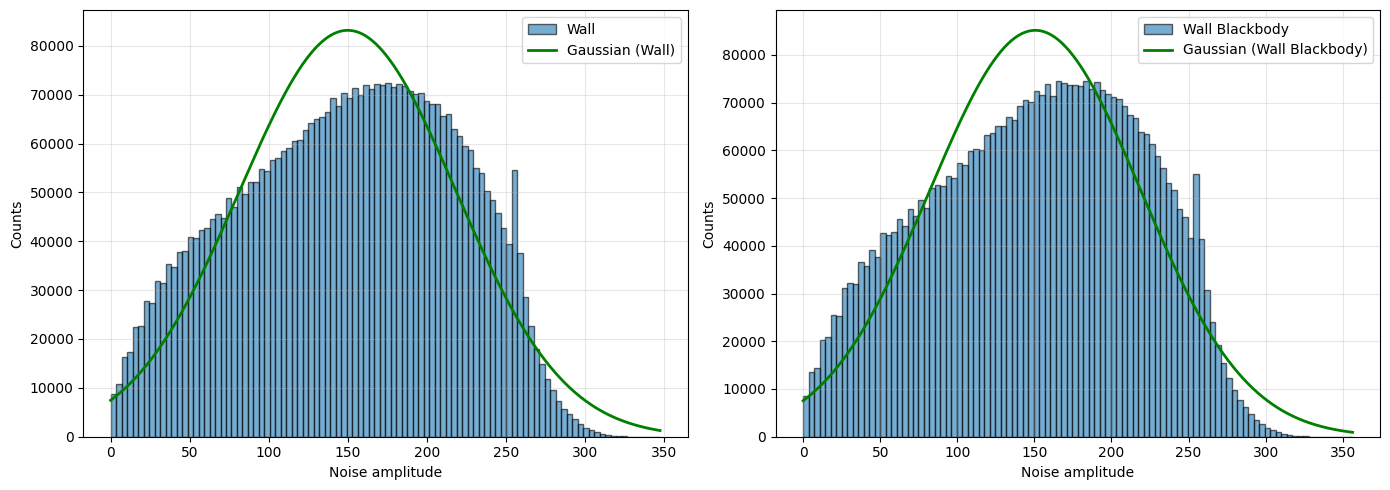

Wall noise stats: {'n_samples': 4095999, 'mean': np.float64(149.9448826878933), 'std': np.float64(68.2732447265701), 'min': np.float64(0.0), 'max': np.float64(347.4492768736179)}
Wall Blackbody noise stats: {'n_samples': 4095999, 'mean': np.float64(150.61346060942455), 'std': np.float64(68.39639625551023), 'min': np.float64(0.0), 'max': np.float64(356.4070706369334)}


In [12]:
# Noise histograms for wall datasets (wall and wall_blackbody)

fs = 2e6  # sampling frequency (Hz)

def plot_noise_hist_for(samples_arr, fs, label, ax):
    # concatenate blocks and form complex signal
    flat = samples_arr.reshape(-1, 2)
    x = flat[:,0] + 1j*flat[:,1]
    noise = np.diff(x)
    noise_abs = np.abs(noise)

    bins = 100
    counts, edges, _ = ax.hist(noise_abs, bins=bins, edgecolor='black', alpha=0.6, label=f"{label}")
    bin_width = edges[1] - edges[0]

    mu = np.mean(noise_abs)
    sigma = np.std(noise_abs, ddof=1)
    x_gauss = np.linspace(edges[0], edges[-1], 1000)
    gauss_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_gauss - mu)/sigma)**2)
    gauss_counts = gauss_pdf * len(noise_abs) * bin_width
    ax.plot(x_gauss, gauss_counts, color='green', linewidth=2, label=f"Gaussian ({label})")
    ax.set_xlabel('Noise amplitude')
    ax.set_ylabel('Counts')
    ax.grid(True, alpha=0.3)
    ax.legend()

    stats = {
        'n_samples': len(noise_abs),
        'mean': mu,
        'std': sigma,
        'min': np.min(noise_abs),
        'max': np.max(noise_abs)
    }
    return stats

# Load wall datasets
data_wall = np.load("bighorn_wall.npz")
samples_wall = data_wall["samples"]

data_wall_bb = np.load("bighorn_wall_blackbody.npz")
samples_wall_bb = data_wall_bb["samples"]

fig, axs = plt.subplots(1, 2, figsize=(14,5))

stats_wall = plot_noise_hist_for(samples_wall, fs, 'Wall', axs[0])
stats_wall_bb = plot_noise_hist_for(samples_wall_bb, fs, 'Wall Blackbody', axs[1])

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/noise_histograms_wall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('Wall noise stats:', stats_wall)
print('Wall Blackbody noise stats:', stats_wall_bb)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:857: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7096: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


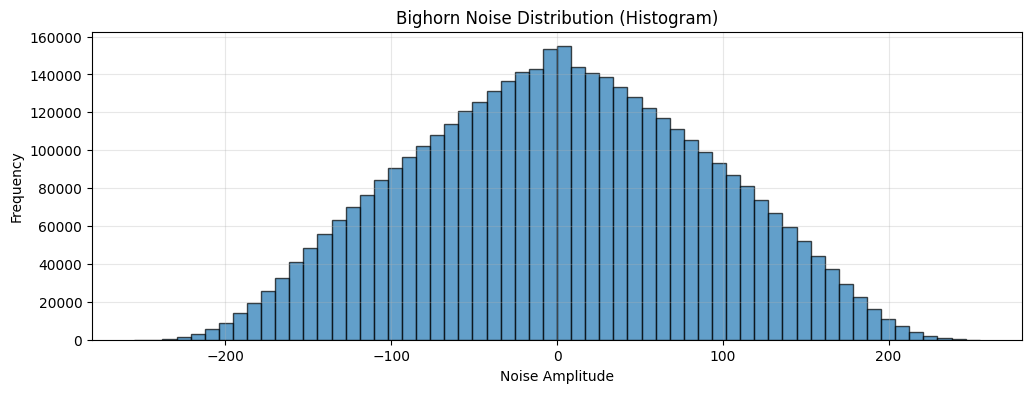

Noise Mean: 2.832032e-05-2.172852e-05j
Noise Std Dev: 1.647565e+02
Noise Min: -2.550000e+02-2.270000e+02j
Noise Max: 2.550000e+02+2.180000e+02j


In [13]:
fs = 2e6  # sampling frequency

data_wall = np.load("bighorn_wall.npz")
samples_wall = data_wall["samples"]

# Flatten all blocks and extract I and Q channels
samples_flat = samples_wall.reshape(-1, 2)  # reshape to (total_samples, 2)
I = samples_flat[:, 0]  # In-phase
Q = samples_flat[:, 1]  # Quadrature

# Generate time array
t = np.arange(len(I)) / fs

# Create complex signal
x = I + 1j * Q

# Noise distribution analysis for bighorn data
# Compute noise as the difference between consecutive samples

# Use the complex signal we already created
noise_bighorn = np.diff(x)

plt.figure(figsize=(12, 4))
plt.hist(noise_bighorn, bins=60, edgecolor='black', alpha=0.7)
plt.xlabel("Noise Amplitude")
plt.ylabel("Frequency")
plt.title("Bighorn Noise Distribution (Histogram)")
plt.grid(True, alpha=0.3)
plt.savefig("Lab 2/figures/bighorn_noise_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# Print noise statistics
print(f"Noise Mean: {np.mean(noise_bighorn):.6e}")
print(f"Noise Std Dev: {np.std(noise_bighorn):.6e}")
print(f"Noise Min: {np.min(noise_bighorn):.6e}")
print(f"Noise Max: {np.max(noise_bighorn):.6e}")

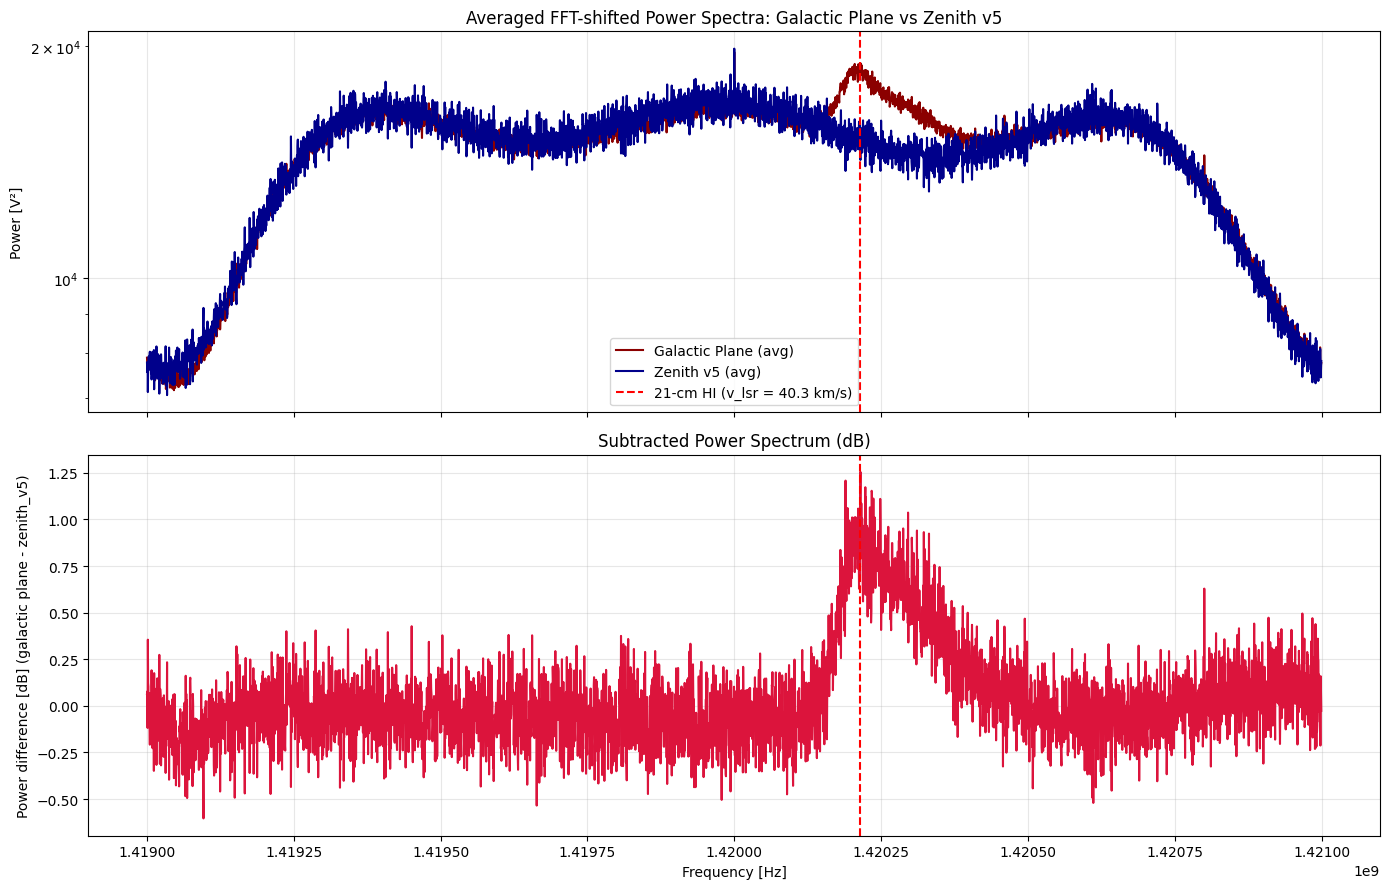

Max dB difference: 1.254 dB at 1.420e+09 Hz
Min dB difference: -0.604 dB at 1.419e+09 Hz
HI line frequency (adjusted): 1.420215e+09 Hz
Doppler shift: 40.32 km/s
Saved figure: Lab 2/figures/galactic_plane_minus_zenith_v5_difference.png


In [16]:
# Subtracted averaged fftshifted power spectrum: galactic plane - zenith v5
# Loads `bighorn_galactic_plane.npz` and `bighorn_zenith_v5.npz`, averages fftshifted power per block, subtracts and plots
# Includes Doppler shift for HI line based on velocity

# === Doppler/redshift parameters ===
f_HI_rest = 1420.40575177e6  # Rest frequency of 21 cm HI line [Hz]
c = 3e8  # Speed of light [m/s]
v_lsr = 40.32  # Line-of-sight velocity relative to LSR [km/s]. Positive = receding, Negative = approaching

# Convert velocity to frequency shift (Doppler formula, non-relativistic approximation valid for v << c)
# For small velocities: Δf/f ≈ -v/c (negative because receding increases wavelength)
f_HI = f_HI_rest * (1.0 - v_lsr * 1000 / c)  # Convert km/s to m/s

fn_gal = "bighorn_galactic_plane.npz"
fn_zen_v5 = "bighorn_zenith_v5.npz"

data_gal = np.load(fn_gal)
data_zen_v5 = np.load(fn_zen_v5)

samples_gal = data_gal["samples"]
samples_zen_v5 = data_zen_v5["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) / N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_gal, Pgal = avg_shifted_power(samples_gal, fs_local)
freq_zen_v5, Pzen_v5 = avg_shifted_power(samples_zen_v5, fs_local)

# align frequency axes if needed
if len(freq_gal) != len(freq_zen_v5) or not np.allclose(freq_gal, freq_zen_v5):
    fmin = max(freq_gal.min(), freq_zen_v5.min())
    fmax = min(freq_gal.max(), freq_zen_v5.max())
    npts = min(len(freq_gal), len(freq_zen_v5))
    f_common = np.linspace(fmin, fmax, npts)
    Pgal_i = np.interp(f_common, freq_gal, Pgal)
    Pzen_v5_i = np.interp(f_common, freq_zen_v5, Pzen_v5)
    f_plot = f_common
    Pgal_plot = Pgal_i
    Pzen_v5_plot = Pzen_v5_i
else:
    f_plot = freq_gal
    Pgal_plot = Pgal
    Pzen_v5_plot = Pzen_v5

# subtraction
Pdiff = Pgal_plot - Pzen_v5_plot
Pdiff_db = 10*np.log10(Pgal_plot + 1e-20) - 10*np.log10(Pzen_v5_plot + 1e-20)

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(14,9), sharex=True)
ax1.plot(f_plot, Pgal_plot, label='Galactic Plane (avg)', color='darkred')
ax1.plot(f_plot, Pzen_v5_plot, label='Zenith v5 (avg)', color='darkblue')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra: Galactic Plane vs Zenith v5')
ax1.grid(True, alpha=0.3)
ax1.axvline(f_HI, color='red', linestyle='--', label=f'21-cm HI (v_lsr = {v_lsr:.1f} km/s)')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (galactic plane - zenith_v5)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha=0.3)
ax2.axvline(f_HI, color='red', linestyle='--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok=True)
outfn = 'Lab 2/figures/galactic_plane_minus_zenith_v5_difference.png'
plt.savefig(outfn, dpi=300, bbox_inches='tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"HI line frequency (adjusted): {f_HI:.6e} Hz")
print(f"Doppler shift: {v_lsr:.2f} km/s")
print(f"Saved figure: {outfn}")

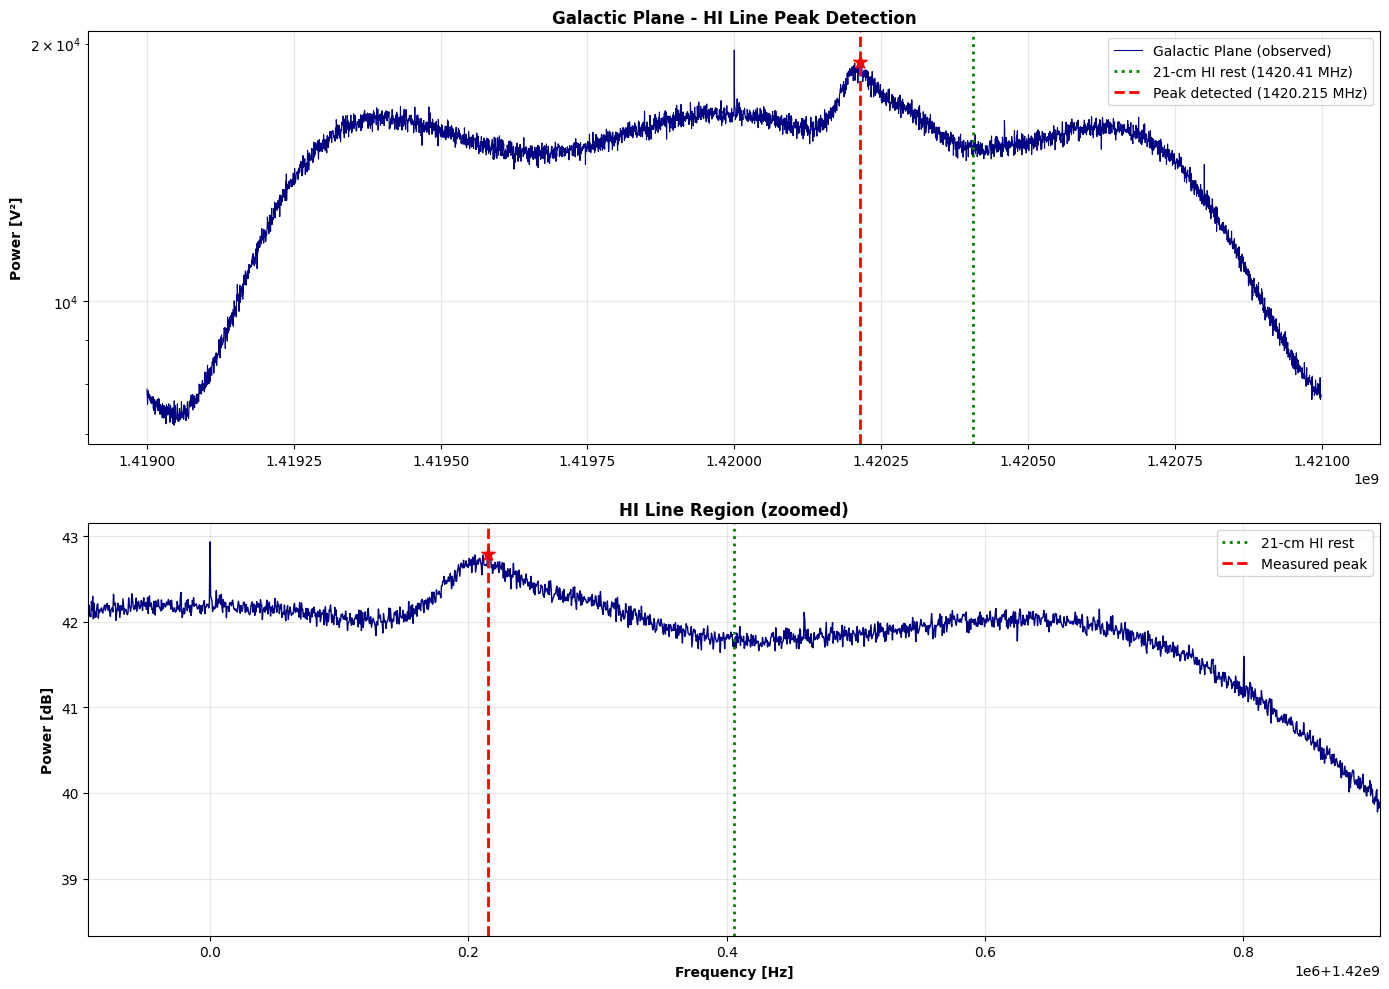

HI LINE VELOCITY MEASUREMENT
Rest frequency (21-cm HI):     1.420406e+09 Hz (1420.405752 MHz)
Observed frequency (peak):     1.420215e+09 Hz (1420.214844 MHz)
Frequency shift:               -1.909e+05 Hz (-190.908 kHz)

MEASURED VELOCITY:             +40.32 km/s

Interpretation:
  → Material receding at 40.32 km/s (redshifted)


In [15]:
# Measure velocity from HI line peak
# Finds the peak frequency in the galactic plane spectrum and calculates velocity

# Load data
fn_gal = "bighorn_galactic_plane.npz"
data_gal = np.load(fn_gal)
samples_gal = data_gal["samples"]

fs_local = 2e6
f_offset = 1420e6
f_HI_rest = 1420.40575177e6  # Rest frequency [Hz]
c = 3e8  # Speed of light [m/s]

# Compute averaged fftshifted power spectrum
num_blocks = samples_gal.shape[0]
N = samples_gal.shape[1]
power_acc = np.zeros(N, dtype=float)

for i in range(num_blocks):
    block = samples_gal[i]
    I_blk = block[:, 0]
    Q_blk = block[:, 1]
    x_blk = I_blk + 1j * Q_blk
    X_blk = np.fft.fft(x_blk)
    X_shift = np.fft.fftshift(X_blk)
    power_shift = (np.abs(X_shift)**2) / N
    power_acc += power_shift

power_avg = power_acc / num_blocks

# Frequency axis (shifted)
freqs = np.fft.fftfreq(N, 1 / fs_local)
freqs_shift = np.fft.fftshift(freqs) + f_offset

# Find peak in power spectrum near the HI line frequency
# Search window around expected HI frequency (±500 kHz)
# BUT exclude DC component by avoiding the center (±50 kHz)
search_window = 500e3  # Hz
dc_tolerance = 50e3  # Hz - exclude DC spike
mask = (freqs_shift >= f_HI_rest - search_window) & (freqs_shift <= f_HI_rest + search_window)
# Also exclude the exact center (DC component)
mask = mask & ((freqs_shift < f_offset - dc_tolerance) | (freqs_shift > f_offset + dc_tolerance))
freqs_window = freqs_shift[mask]
power_window = power_avg[mask]

# Find peak
peak_idx = np.argmax(power_window)
f_observed = freqs_window[peak_idx]
power_peak = power_window[peak_idx]

# Calculate velocity from frequency shift (Doppler formula)
# v = (f_rest - f_obs) / f_rest * c
# Or: v = c * (f_rest - f_obs) / f_rest
velocity_measured = c * (f_HI_rest - f_observed) / f_HI_rest / 1000  # Convert to km/s

# Plot power spectrum with measured peak
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Full spectrum
ax1.plot(freqs_shift, power_avg, color='navy', linewidth=0.8, label='Galactic Plane (observed)')
ax1.axvline(f_HI_rest, color='green', linestyle=':', linewidth=2, label=f'21-cm HI rest ({f_HI_rest/1e6:.2f} MHz)')
ax1.axvline(f_observed, color='red', linestyle='--', linewidth=2, label=f'Peak detected ({f_observed/1e6:.3f} MHz)')
ax1.scatter(f_observed, power_peak, color='red', s=100, zorder=5, marker='*')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]', weight='semibold')
ax1.set_title('Galactic Plane - HI Line Peak Detection', weight='semibold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Zoomed in on HI line region
ax2.plot(freqs_shift, 10*np.log10(power_avg + 1e-20), color='navy', linewidth=1)
ax2.axvline(f_HI_rest, color='green', linestyle=':', linewidth=2, label='21-cm HI rest')
ax2.axvline(f_observed, color='red', linestyle='--', linewidth=2, label=f'Measured peak')
ax2.scatter(f_observed, 10*np.log10(power_peak + 1e-20), color='red', s=100, zorder=5, marker='*')
ax2.set_xlabel('Frequency [Hz]', weight='semibold')
ax2.set_ylabel('Power [dB]', weight='semibold')
ax2.set_title('HI Line Region (zoomed)', weight='semibold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Set x-axis zoom around HI line
ax2.set_xlim(f_HI_rest - 500e3, f_HI_rest + 500e3)

plt.tight_layout()
os.makedirs('Lab 2/figures', exist_ok=True)
plt.savefig('Lab 2/figures/velocity_measurement_HI_peak.png', dpi=300, bbox_inches='tight')
plt.show()

# Print results
print("="*60)
print("HI LINE VELOCITY MEASUREMENT")
print("="*60)
print(f"Rest frequency (21-cm HI):     {f_HI_rest:.6e} Hz ({f_HI_rest/1e6:.6f} MHz)")
print(f"Observed frequency (peak):     {f_observed:.6e} Hz ({f_observed/1e6:.6f} MHz)")
print(f"Frequency shift:               {f_observed - f_HI_rest:.3e} Hz ({(f_observed - f_HI_rest)/1e3:.3f} kHz)")
print(f"\nMEASURED VELOCITY:             {velocity_measured:+.2f} km/s")
print("\nInterpretation:")
if velocity_measured > 0:
    print(f"  → Material receding at {velocity_measured:.2f} km/s (redshifted)")
else:
    print(f"  → Material approaching at {abs(velocity_measured):.2f} km/s (blueshifted)")
print("="*60)